<a href="https://colab.research.google.com/github/CodeHunterOfficial/ArabovMKDeep/blob/main/ADPs/Lecture_6/%D0%9B%D0%B5%D0%BA%D1%86%D0%B8%D1%8F_6_%D0%9E%D0%B1%D1%83%D1%87%D0%B5%D0%BD%D0%B8%D0%B5_%D0%BC%D0%BE%D0%B4%D0%B5%D0%BB%D0%B5%D0%B9_%D0%BA%D0%B0%D0%BA_%D1%8D%D1%82%D0%BE_%D1%80%D0%B0%D0%B1%D0%BE%D1%82%D0%B0%D0%B5%D1%82.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Лекция №6: Обучение моделей: как это работает


## 1. ВВЕДЕНИЕ

### 1.1. От теории к практике: постановка проблемы

В Лекции 5 мы рассмотрели архитектуру современных NLP-моделей — трансформеров, BERT, GPT — и обсудили концепцию предобучения (pre-training) и дообучения (fine-tuning). Мы узнали, что эти модели изначально обучаются на огромных корпусах текстов (миллиарды слов), а затем адаптируются к конкретным задачам с помощью дообучения на размеченных датасетах.

Однако остался открытым вопрос: **что на самом деле происходит в процессе дообучения?** Когда мы запускаем `trainer.train()` в среде Hugging Face, какие процессы запускаются «под капотом»? Как модель «понимает», что она ошиблась, и каким образом она корректирует свои внутренние параметры?

**Цель данной лекции** — раскрыть механизмы обучения нейросетей на интуитивном уровне, без использования математических формул, но с сохранением научной строгости. Мы рассмотрим:

1. Сущность процесса обучения как настройки параметров модели.
2. Роль функции потерь (loss function) в оценке ошибок модели.
3. Алгоритм градиентного спуска (gradient descent) как метод коррекции параметров.
4. Различие между параметрами (обучаемыми величинами) и гиперпараметрами (настройками, задаваемыми исследователем).
5. Принципы разделения данных на обучающую, валидационную и тестовую выборки.
6. Интерпретацию графиков обучения (кривые loss и accuracy).
7. Систему метрик оценки качества классификации (accuracy, precision, recall, F1) и их применение в клинической психологии.

**Ключевая мысль:** понимание процесса обучения — это **ключ к критической оценке** любой ИИ-системы. Если вы понимаете, как модель учится, вы понимаете, **когда ей можно доверять, а когда нет**. В клинической психологии, где цена ошибки особенно высока, это знание становится **этической необходимостью** [7].

---

### 1.2. Актуальность для клинической психологии

В последние годы наблюдается активное внедрение методов машинного обучения в психиатрию и клиническую психологию. Согласно обзору [5], количество публикаций по применению NLP в диагностике психических расстройств выросло в 3 раза за период 2020–2025 годов. Модели используются для:

- Скрининга депрессии по текстам сообщений пациентов.
- Оценки суицидального риска на основе анализа дневниковых записей.
- Классификации эмоциональных состояний в терапевтических диалогах.
- Прогнозирования эффективности психотерапии.

Однако, как отмечается в работе [7], многие клиницисты не имеют достаточного понимания принципов работы этих моделей, что создаёт риски необоснованного доверия или, наоборот, неоправданного скепсиса. Настоящая лекция призвана заполнить этот пробел.

---

### 1.3. Структура и методология

Лекция построена по принципу «от общего к частному». Каждый новый концепт вводится через аналогию из психотерапевтической практики, а затем раскрывается на уровне, достаточном для понимания процессов, происходящих при дообучении моделей. В конце каждого раздела даётся отсылка к Практике 6, где студенты могут наблюдать описанные процессы в действии.




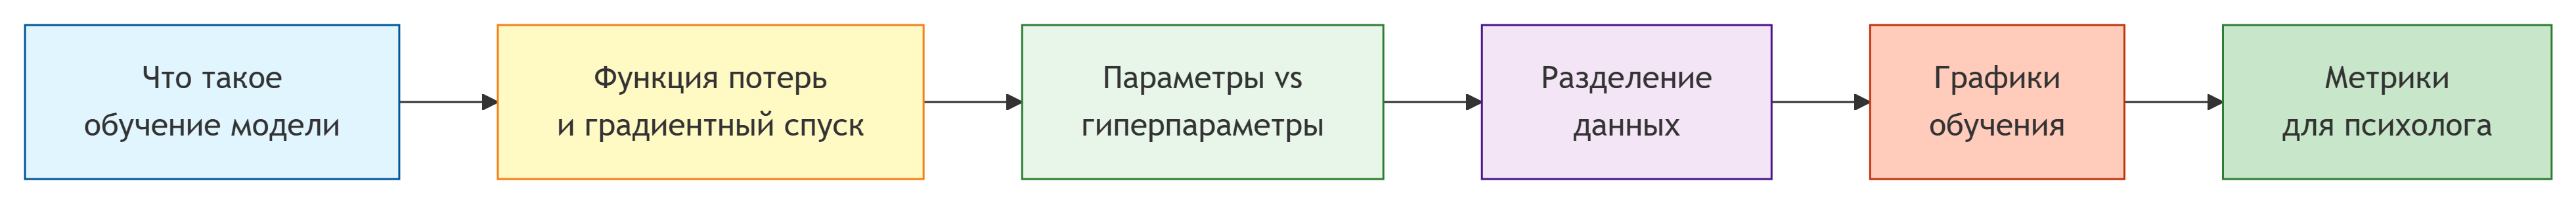



### 1.4. Связь с предыдущими лекциями и практикой

| Предыдущий материал | Связь с текущей темой |
|---------------------|----------------------|
| **Лекция 5.** Архитектура трансформеров, предобучение и дообучение | Сегодня мы раскрываем **механизмы** дообучения — что происходит внутри модели |
| **Практика 6.** Запуск дообучения, построение графиков | Сегодня мы объясняем **почему** графики выглядят так, а не иначе |
| **Лекция 4.** Визуализация данных | Сегодня мы учимся **интерпретировать** графики обучения |

---

### 1.5. Этический контекст

В соответствии с принципами ответственного применения ИИ в медицине [7], важно подчеркнуть: модели машинного обучения не являются заменой клиническому мышлению. Они представляют собой инструменты, которые могут **поддерживать** принятие решений, но не **заменять** его. Понимание механизмов обучения позволяет клиницисту:

- Критически оценивать заявленные показатели точности.
- Выявлять потенциальные источники ошибок (смещение выборки, переобучение).
- Принимать обоснованные решения о целесообразности использования модели.
- Объяснять пациентам принципы работы ИИ-систем.

---

## 2. ЧТО ЗНАЧИТ «ОБУЧИТЬ МОДЕЛЬ»

### 2.1. Модель как параметрическая функция

В современном машинном обучении модель представляет собой **параметрическую функцию** — математическое выражение, которое преобразует входные данные (например, текст) в выходные данные (например, класс эмоции). Параметры функции — это числа, которые определяют характер этого преобразования [1], [2].

**Техническое уточнение:** в случае нейросетей параметрами являются веса связей между нейронами (synaptic weights) и смещения (biases). В модели ruBERT, используемой в Практике 6, таких параметров **178 миллионов** — каждый из них представляет собой число с плавающей точкой.

**Интуитивная аналогия (для понимания):**

> Представьте, что модель — это сложный музыкальный синтезатор с миллионами регуляторов. Каждый регулятор соответствует одному параметру. Изначально регуляторы находятся в случайных положениях — синтезатор издаёт хаотичный шум. В процессе обучения регуляторы постепенно настраиваются так, чтобы синтезатор начинал воспроизводить определённую мелодию.

**Определение обучения:** обучение модели — это процесс последовательной настройки параметров с целью минимизации ошибки на обучающих данных [3].

---

### 2.2. Процесс обучения как итеративная коррекция

**Интуитивная аналогия из психотерапии (расширенная версия):**

> Представьте, что вы — супервизор, и к вам пришёл молодой терапевт. У него есть теоретические знания (аналог предобученной модели), но нет клинического опыта. Вы даёте ему 1000 клинических случаев (обучающий датасет). Для каждого случая он предлагает интерпретацию, а вы сообщаете правильный ответ.
>
> Каждый раз, когда он ошибается, он **корректирует свой подход** — не в общем смысле, а в конкретных аспектах: учится замечать определённые паттерны, различать похожие состояния, обращать внимание на ключевые симптомы. Эти корректировки постепенно накапливаются, и после 1000 случаев его точность значительно возрастает.
>
> Важно понимать: терапевт не «запоминает» случаи (это было бы переобучением). Он извлекает **общие закономерности**, которые позволяют ему работать с новыми, незнакомыми случаями.

**Как это происходит в нейросети:**

1. На вход подаётся пример (текст + правильная эмоция).
2. Модель выполняет прямое распространение (forward pass) — данные проходят через все слои, и на выходе формируется предсказание (вероятности для каждого класса).
3. Вычисляется ошибка (loss) — сравнение предсказания с правильным ответом с помощью функции потерь.
4. Выполняется обратное распространение (backward pass) — вычисляется градиент, показывающий, как нужно изменить каждый параметр, чтобы уменьшить ошибку.
5. Параметры обновляются — делается шаг в направлении, указанном градиентом.
6. Процесс повторяется со следующим примером.

**Связь с Практикой 6:** в нашей практике мы использовали `Trainer` из библиотеки Hugging Face, который автоматизирует все эти шаги. Когда мы запускали `trainer.train()`, выполнялись тысячи итераций этого цикла.

---

### 2.3. Функция потерь (Loss Function): количественная оценка ошибки

**Определение:** функция потерь (loss function) — это математическая функция, которая вычисляет **числовое значение**, отражающее расхождение между предсказанием модели и правильным ответом. Чем больше расхождение, тем выше значение loss [1], [2].

**Техническое уточнение:** в задачах классификации наиболее широко используется **кросс-энтропийная функция потерь** (cross-entropy loss). Она измеряет разницу между распределением вероятностей, предсказанных моделью, и распределением, где правильному классу соответствует вероятность 1. Согласно [3], кросс-энтропия является стандартом для задач классификации благодаря своим хорошим градиентным свойствам.

**Интуитивная аналогия:**

> Представьте, что вы оцениваете работу студента-медика на клиническом разборе. Вы не просто говорите «правильно» или «неправильно» — вы ставите количественную оценку:
> - Точно угадал диагноз → 0 баллов ошибки (loss ≈ 0).
> - Ошибся, но близко (например, спутал депрессию с дистимией) → 1 балл ошибки (loss = 1).
> - Полностью не прав (например, при явной депрессии сказал «маниакальный эпизод») → 10 баллов ошибки (loss = 10).
>
> Эта количественная оценка позволяет студенту понять **степень** своей ошибки и соответственно скорректировать подход.

**Пример из нашей практики (классификация эмоций):**

Рассмотрим два сценария для текста *«Я так устала от всего этого»* (правильный класс — грусть):

**Сценарий А (малая ошибка):**
- Гнев: 5%
- Страх: 10%
- Радость: 5%
- Грусть: 80%

Loss будет низким (≈0.2), так как модель присвоила высокую вероятность правильному классу.

**Сценарий Б (большая ошибка):**
- Гнев: 40%
- Страх: 30%
- Радость: 20%
- Грусть: 10%

Loss будет высоким (≈2.3), так как правильный класс получил низкую вероятность.

**Почему loss, а не accuracy?** Accuracy показывает только долю правильных ответов, но не учитывает **уверенность** модели. Loss чувствителен к уверенности: модель, которая даёт 80% на правильный класс, получает меньший loss, чем модель, дающая 51%, даже если обе «правильны». Это позволяет модели обучаться более плавно [3].

**Связь с Практикой 6:** на графиках мы видели, как **loss снижается** в процессе обучения. Это значит, что модель постепенно учится давать правильные ответы — ошибка становится меньше с каждой эпохой.

---

### 2.4. Градиентный спуск (Gradient Descent): механизм коррекции ошибок

**Определение:** градиентный спуск — это итеративный алгоритм оптимизации, который вычисляет **направление наискорейшего уменьшения** функции потерь и обновляет параметры модели в этом направлении [1], [2].

**Интуитивная аналогия (адаптирована для психологов):**

> Представьте, что вы оказались в горах в густом тумане и хотите спуститься в долину (где ошибка минимальна). Вы не видите всю гору, но можете оценить **локальный уклон** под ногами. Вы делаете шаг в сторону самого крутого спуска. Затем снова оцениваете уклон и делаете следующий шаг. Постепенно вы достигаете долины.
>
> **Соответствие:**
> - Гора = пространство всех возможных значений параметров модели.
> - Долина = набор параметров, при которых ошибка минимальна.
> - Уклон = градиент (производная), показывающий направление уменьшения ошибки.
> - Шаг = обновление параметров (размер шага контролируется learning rate).

**Математическая суть (без формул):**

Градиент — это вектор, указывающий направление **наибольшего возрастания** функции. Чтобы уменьшить функцию, мы двигаемся в **противоположном направлении**. Модель вычисляет градиент (через алгоритм обратного распространения ошибки) и обновляет параметры, сдвигая их на небольшую величину в сторону, противоположную градиенту.

**Роль learning rate (скорости обучения):**

Learning rate — это гиперпараметр, который определяет **размер шага** при обновлении параметров [4].

| Learning rate | Размер шага | Эффект | Аналогия |
|---------------|-------------|--------|----------|
| **Слишком малый (1e-5)** | Очень маленький | Медленная сходимость, но стабильная | Идти мелкими шагами — дойдёте, но долго |
| **Оптимальный (2e-5)** | Умеренный | Быстрая и стабильная сходимость | Идти уверенным шагом — оптимально |
| **Слишком большой (5e-5)** | Большой | Нестабильность, возможен «перескок» минимума | Прыгать с камня на камень — можно упасть |

**Эмпирическое наблюдение:** согласно исследованиям [6], для дообучения BERT-подобных моделей оптимальным значением learning rate является диапазон 2e-5 — 5e-5. Это значение используется в Практике 6.

---

### 2.5. Схема: один шаг обучения




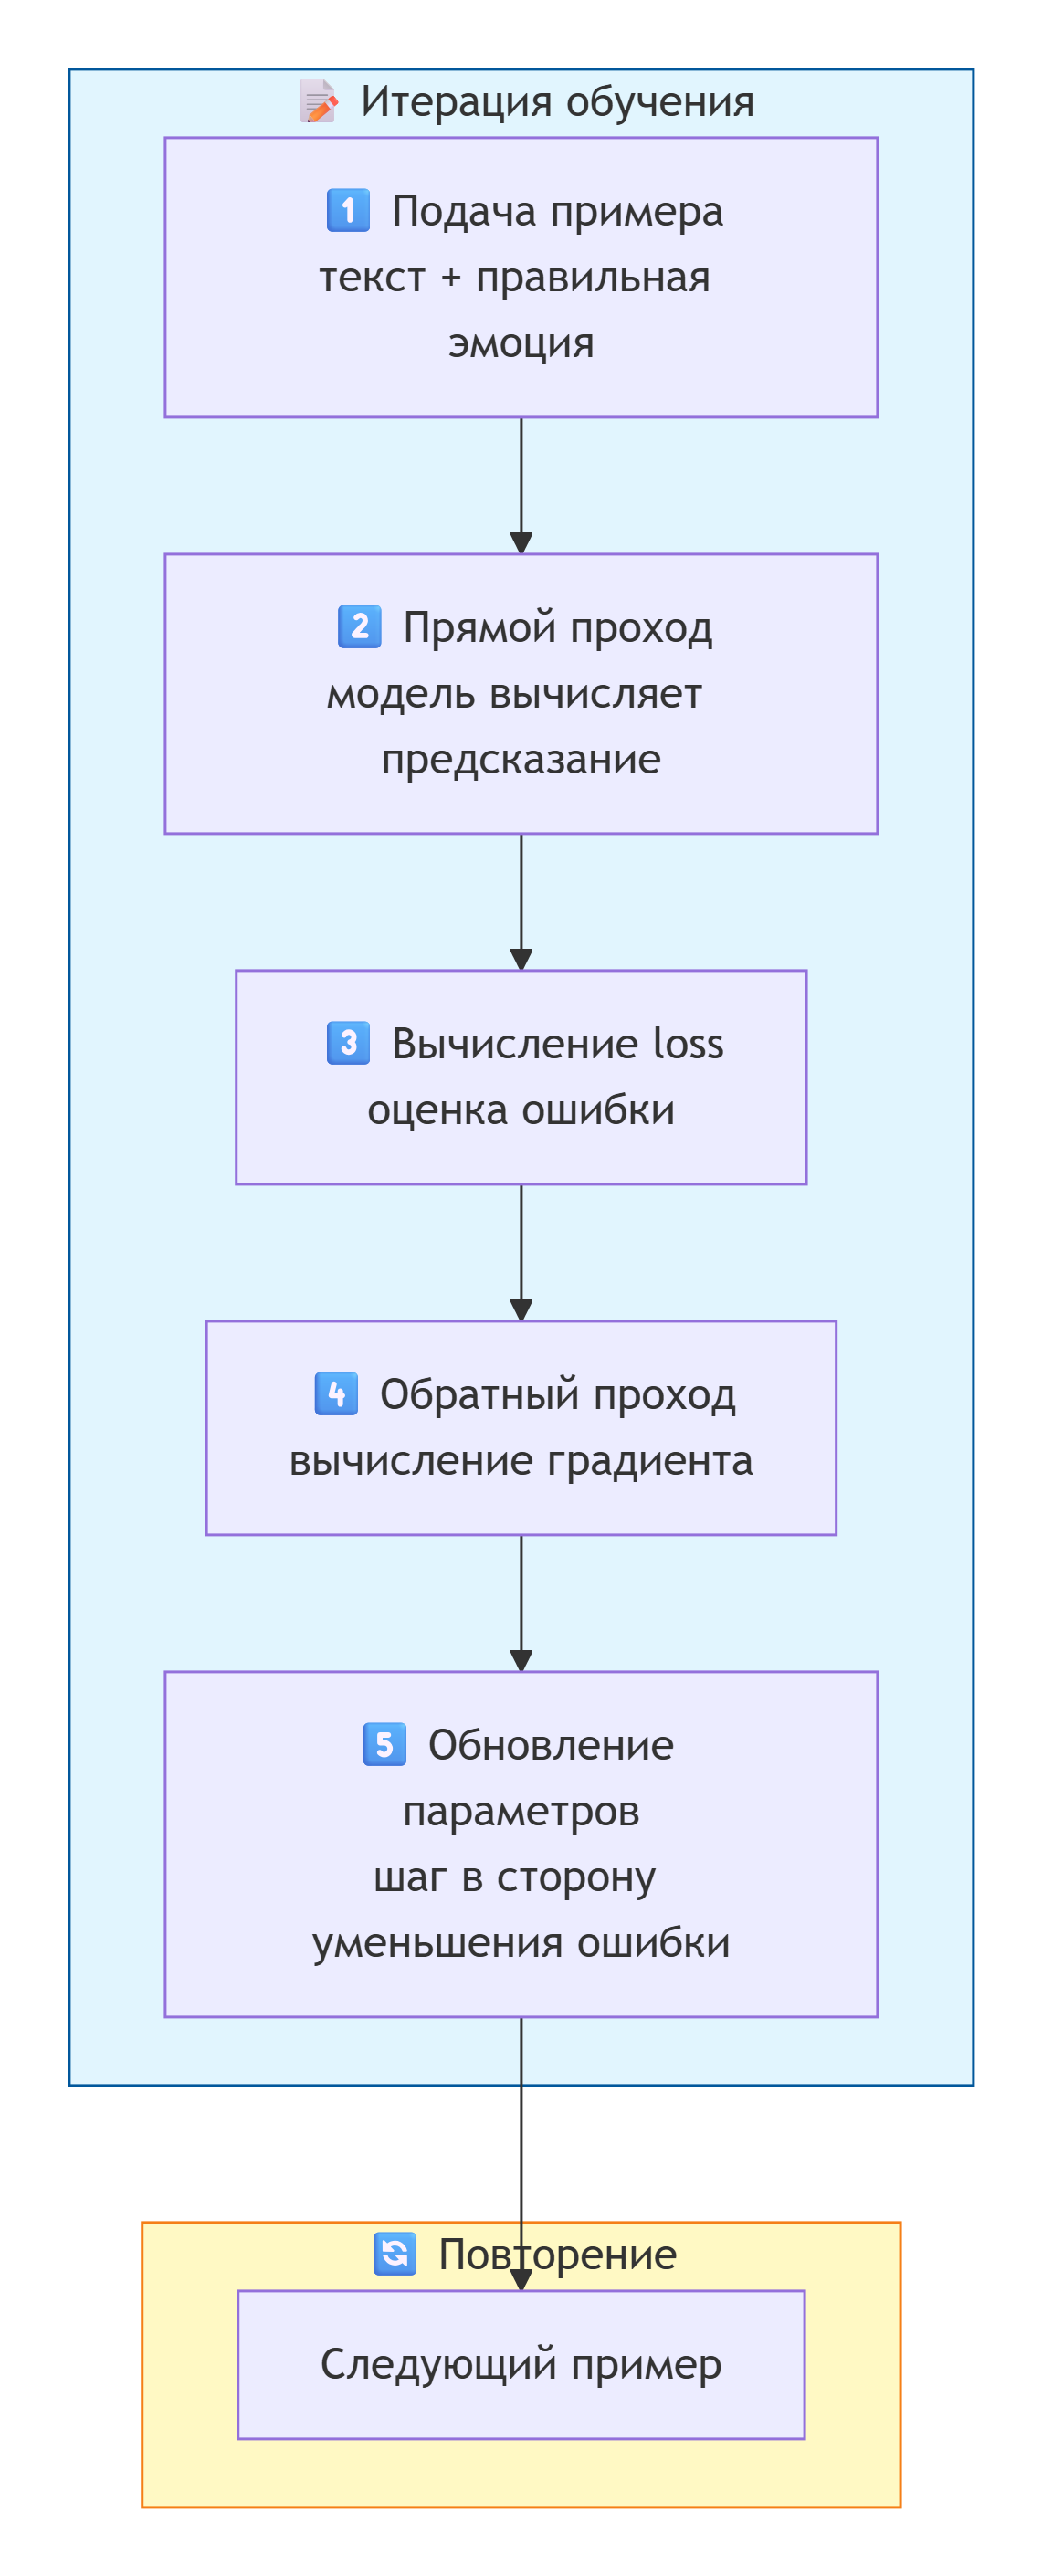


**Пошаговое пояснение:**

1. **Подача примера:** Модель получает текст и правильную эмоцию. Это как если бы мы дали стажёру клинический случай и правильный диагноз.

2. **Прямой проход:** Модель пропускает текст через все свои слои и выдаёт вероятности для каждого класса. Стажёр предлагает свою интерпретацию.

3. **Вычисление loss:** Сравниваем предсказание с правильным ответом. Чем больше разница, тем больше loss. Супервизор оценивает, насколько стажёр ошибся.

4. **Обратный проход:** Модель вычисляет градиент — направление, в котором нужно изменить параметры, чтобы уменьшить ошибку. Стажёр понимает, в каком направлении ему нужно корректировать свой подход.

5. **Обновление параметров:** Модель делает шаг в сторону уменьшения ошибки. Стажёр меняет свой подход на основе обратной связи.

6. **Повторение:** Берём следующий пример и повторяем всё сначала.

**Этот процесс повторяется тысячи раз, пока ошибка не перестанет уменьшаться.**

---

### 2.6. Основные выводы раздела

1. Обучение модели — это процесс настройки миллионов параметров с целью минимизации ошибки на обучающих данных.

2. Функция потерь (loss) количественно оценивает расхождение между предсказанием модели и правильным ответом. Снижение loss в процессе обучения является индикатором того, что модель учится.

3. Градиентный спуск — это алгоритм, который вычисляет направление уменьшения ошибки и обновляет параметры в этом направлении.

4. Скорость обучения (learning rate) контролирует размер шага при обновлении параметров и является критическим гиперпараметром.

5. Понимание этих механизмов позволяет клиницисту критически оценивать качество и ограничения ИИ-систем [5], [7].

---

## 3. ПАРАМЕТРЫ VS ГИПЕРПАРАМЕТРЫ

### 3.1. Параметры (Parameters): что модель учит сама

**Определение:** параметры модели — это внутренние переменные, значения которых **определяются в процессе обучения** на основе данных. Модель «учит» их сама, адаптируясь к закономерностям в обучающей выборке [1], [2].

**Техническое уточнение:** в нейросетях параметрами являются веса связей (weights) и смещения (biases). В модели ruBERT, используемой в Практике 6, их **178 миллионов**.

**Интуитивная аналогия:**

> Представьте, что терапевт учится на супервизии. Он **меняет свой подход** к каждому пациенту на основе опыта: запоминает, какие симптомы с чем связаны, учится замечать паттерны, корректирует свои интерпретации. Это его «параметры» — они меняются в процессе обучения.

**Связь с Практикой 6:** когда мы запускали `trainer.train()`, именно эти 178 миллионов чисел **подстраивались** под нашу задачу классификации эмоций.

---

### 3.2. Гиперпараметры (Hyperparameters): что задаём мы

**Определение:** гиперпараметры — это настройки процесса обучения, которые **задаются исследователем до начала обучения** и не изменяются в процессе [3], [4]. Они определяют, **как** модель будет учиться.

**Интуитивная аналогия:**

> Представьте, что терапевт идёт на супервизию. Гиперпараметры — это **условия супервизии**:
> - Сколько раз в неделю встречаться (число эпох).
> - Как быстро терапевт должен усваивать новый опыт (скорость обучения).
> - Сколько случаев разбирать за одну встречу (размер батча).
>
> Терапевт не выбирает эти условия — их выбирает супервизор (мы). Но они сильно влияют на результат.

**Главные гиперпараметры и их влияние:**

| Гиперпараметр | Что это | Аналогия для психолога | Эффект при изменении |
|---------------|---------|------------------------|---------------------|
| **Learning Rate** | Скорость обучения. Насколько сильно меняются параметры на каждом шаге | Как быстро терапевт меняет подход после обратной связи | Слишком большой — «перепрыгивает» оптимум. Слишком маленький — учится очень медленно |
| **Number of Epochs** | Число эпох. Сколько раз модель видит все данные | Сколько раз терапевт пересматривает случаи | Слишком мало — недообучение. Слишком много — переобучение |
| **Batch Size** | Сколько примеров за один шаг | Сколько пациентов в группе | Маленький — быстрее, но «шумнее». Большой — стабильнее, но медленнее |
| **Weight Decay** | Регуляризация. Штраф за сложность модели | Ограничение: терапевт не должен усложнять интерпретацию без нужды | Большой — модель проще, меньше переобучается |

---

### 3.3. Схема: параметры vs гиперпараметры




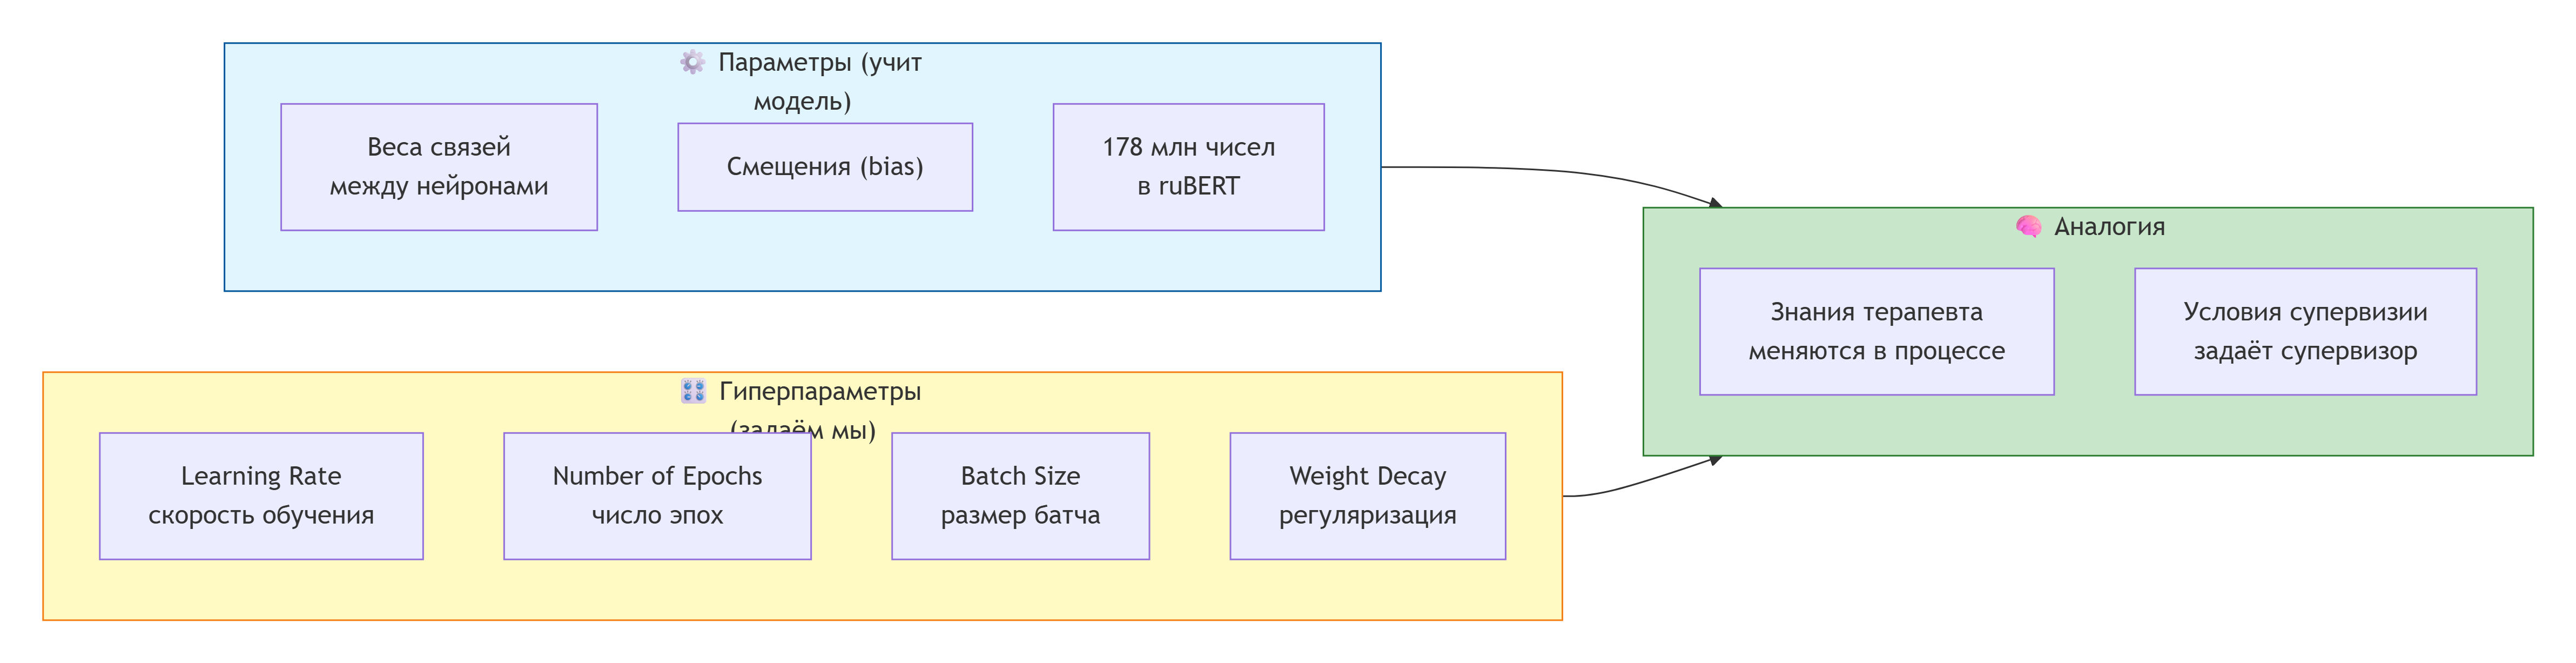


---

### 3.4. Почему это важно для психолога

- **Параметры** — это то, что модель выучила сама. Мы не можем их контролировать напрямую.
- **Гиперпараметры** — это то, что мы контролируем. От их выбора зависит качество обучения.
- Понимание гиперпараметров позволяет **критически оценивать** исследования: если авторы не указывают гиперпараметры, результаты сложно воспроизвести [7].

**Связь с Практикой 6:** мы проводили эксперименты, меняя `learning_rate` и `num_train_epochs`, и наблюдали, как это влияет на accuracy.

---






## 4. РАЗДЕЛЕНИЕ ДАННЫХ: TRAIN, VALIDATION, TEST

### 4.1. Проблема переобучения и необходимость разделения

**Определение:** переобучение (overfitting) — это ситуация, при которой модель запоминает обучающие примеры, но не способна обобщать закономерности на новые, невидимые ранее данные [3]. Это одна из самых распространённых ошибок в машинном обучении, которая приводит к завышенной оценке качества модели на обучающих данных и низкой эффективности в реальной клинической практике.

**Интуитивная аналогия из психологического образования:**

> Представьте, что студент-психолог готовится к экзамену по диагностике депрессии. Ему дают 100 клинических случаев для изучения. Он заучивает их наизусть — запоминает, какой диагноз соответствует каждому описанию. На экзамене ему дают те же 100 случаев — он отвечает идеально. Но когда он приходит на практику к реальному пациенту — он теряется. Он выучил конкретные случаи, но не понял общих диагностических принципов.
>
> В машинном обучении это называется **переобучением**. Модель «запоминает» обучающие примеры, но не учится «обобщать» — выделять закономерности, применимые к новым данным.

**Решение проблемы:** чтобы избежать переобучения и получить объективную оценку качества модели, данные разделяют на три независимые выборки: обучающую (train), валидационную (validation) и тестовую (test) [4].

---

### 4.2. Три типа выборок: назначение и функции

Каждая из трёх выборок выполняет свою уникальную функцию в процессе обучения. Понимание этих функций критически важно для корректной оценки модели.

| Выборка | Назначение | Аналогия в психологии | Особенности использования |
|---------|------------|----------------------|--------------------------|
| **Train** (обучающая) | Модель учится на этих данных. Только на них модель «видит» правильные ответы | Учебные кейсы, которые студент разбирает с супервизором | Модель подстраивает параметры, минимизируя ошибку на этих данных |
| **Validation** (валидационная) | Настройка гиперпараметров и ранняя остановка обучения. Модель **не учится** на этих данных | Контрольные работы, показывающие уровень усвоения материала | Мы оцениваем ошибку модели, но не обновляем параметры. Используется для выбора гиперпараметров |
| **Test** (тестовая) | **Однократная** финальная оценка качества модели. Модель никогда не видела эти данные | Финальный экзамен по новым, незнакомым случаям | Используется **только один раз** в конце обучения для получения объективной оценки |

**Ключевое методологическое правило:** тестовая выборка должна использоваться **строго один раз** — для финальной оценки модели. Любое использование тестовых данных для настройки модели (выбора гиперпараметров, ранней остановки) делает оценку необъективной [4].

**Типичное распределение данных:** в практике машинного обучения принято распределять данные в пропорции 70/15/15 или 80/10/10 [3]. Выбор пропорции зависит от объёма данных: чем больше данных, тем меньшую долю можно выделить на валидацию и тест. При малом объёме данных (менее 1000 примеров) долю валидационной и тестовой выборок можно увеличить до 20–25% каждая.

**Почему именно такие пропорции?**
- **Train (70–80%)** — достаточно данных, чтобы модель увидела разнообразие паттернов.
- **Validation (10–15%)** — достаточно данных, чтобы надёжно оценить качество настройки гиперпараметров.
- **Test (10–15%)** — достаточно данных, чтобы получить статистически значимую оценку финального качества.

---

### 4.3. Утечка данных (Data Leakage): определение и предотвращение

**Определение:** утечка данных (data leakage) — это ситуация, при которой информация из тестовой или валидационной выборки «просачивается» в процесс обучения модели. Это приводит к **необъективной** оценке качества модели, которая не будет соответствовать её реальной эффективности на новых данных [4].

**Интуитивная аналогия:**

> Представьте, что вы готовите студента к экзамену. Утечка данных — это когда вы даёте ему **те же самые вопросы**, которые будут на экзамене. Он выучит их наизусть, но не поймёт предмет. В реальной практике он не сможет применить знания.

**Типичные ошибки, приводящие к утечке данных:**

| Ошибка | Почему это утечка | Правильное решение |
|--------|-------------------|-------------------|
| **Нормализация всех данных перед разделением** | Параметры нормализации (среднее, стандартное отклонение) вычислены с учётом тестовых данных | Сначала разделить данные, затем нормализовать **только обучающую** выборку, а параметры нормализации применить к валидационной и тестовой |
| **Использование тестовой выборки для настройки гиперпараметров** | Тестовая выборка перестаёт быть «независимой» — модель «подглядывает» ответы | Все настройки выполняются **только** через валидационную выборку. Тест используется **один раз** в конце |
| **Перемешивание данных без учёта времени** | При использовании временных данных (например, записи пациентов за несколько лет) случайное перемешивание может привести к тому, что модель «узнает» будущее | Делить по времени: train — более ранние данные, test — более поздние |

**Стратификация (stratification):** при разделении данных важно сохранять пропорцию классов в каждой выборке. Например, если в общей выборке 20% пациентов с депрессией, то и в обучающей, и в валидационной, и в тестовой выборках должно быть примерно 20% пациентов с депрессией [4]. В противном случае модель может «не научиться» распознавать редкий класс. Стратификация особенно важна в клинических исследованиях, где целевые состояния (депрессия, суицидальный риск) встречаются относительно редко.

---

### 4.4. Схема: правильное разделение данных

На схеме ниже показан полный процесс разделения данных от исходного датасета до финальной оценки модели.




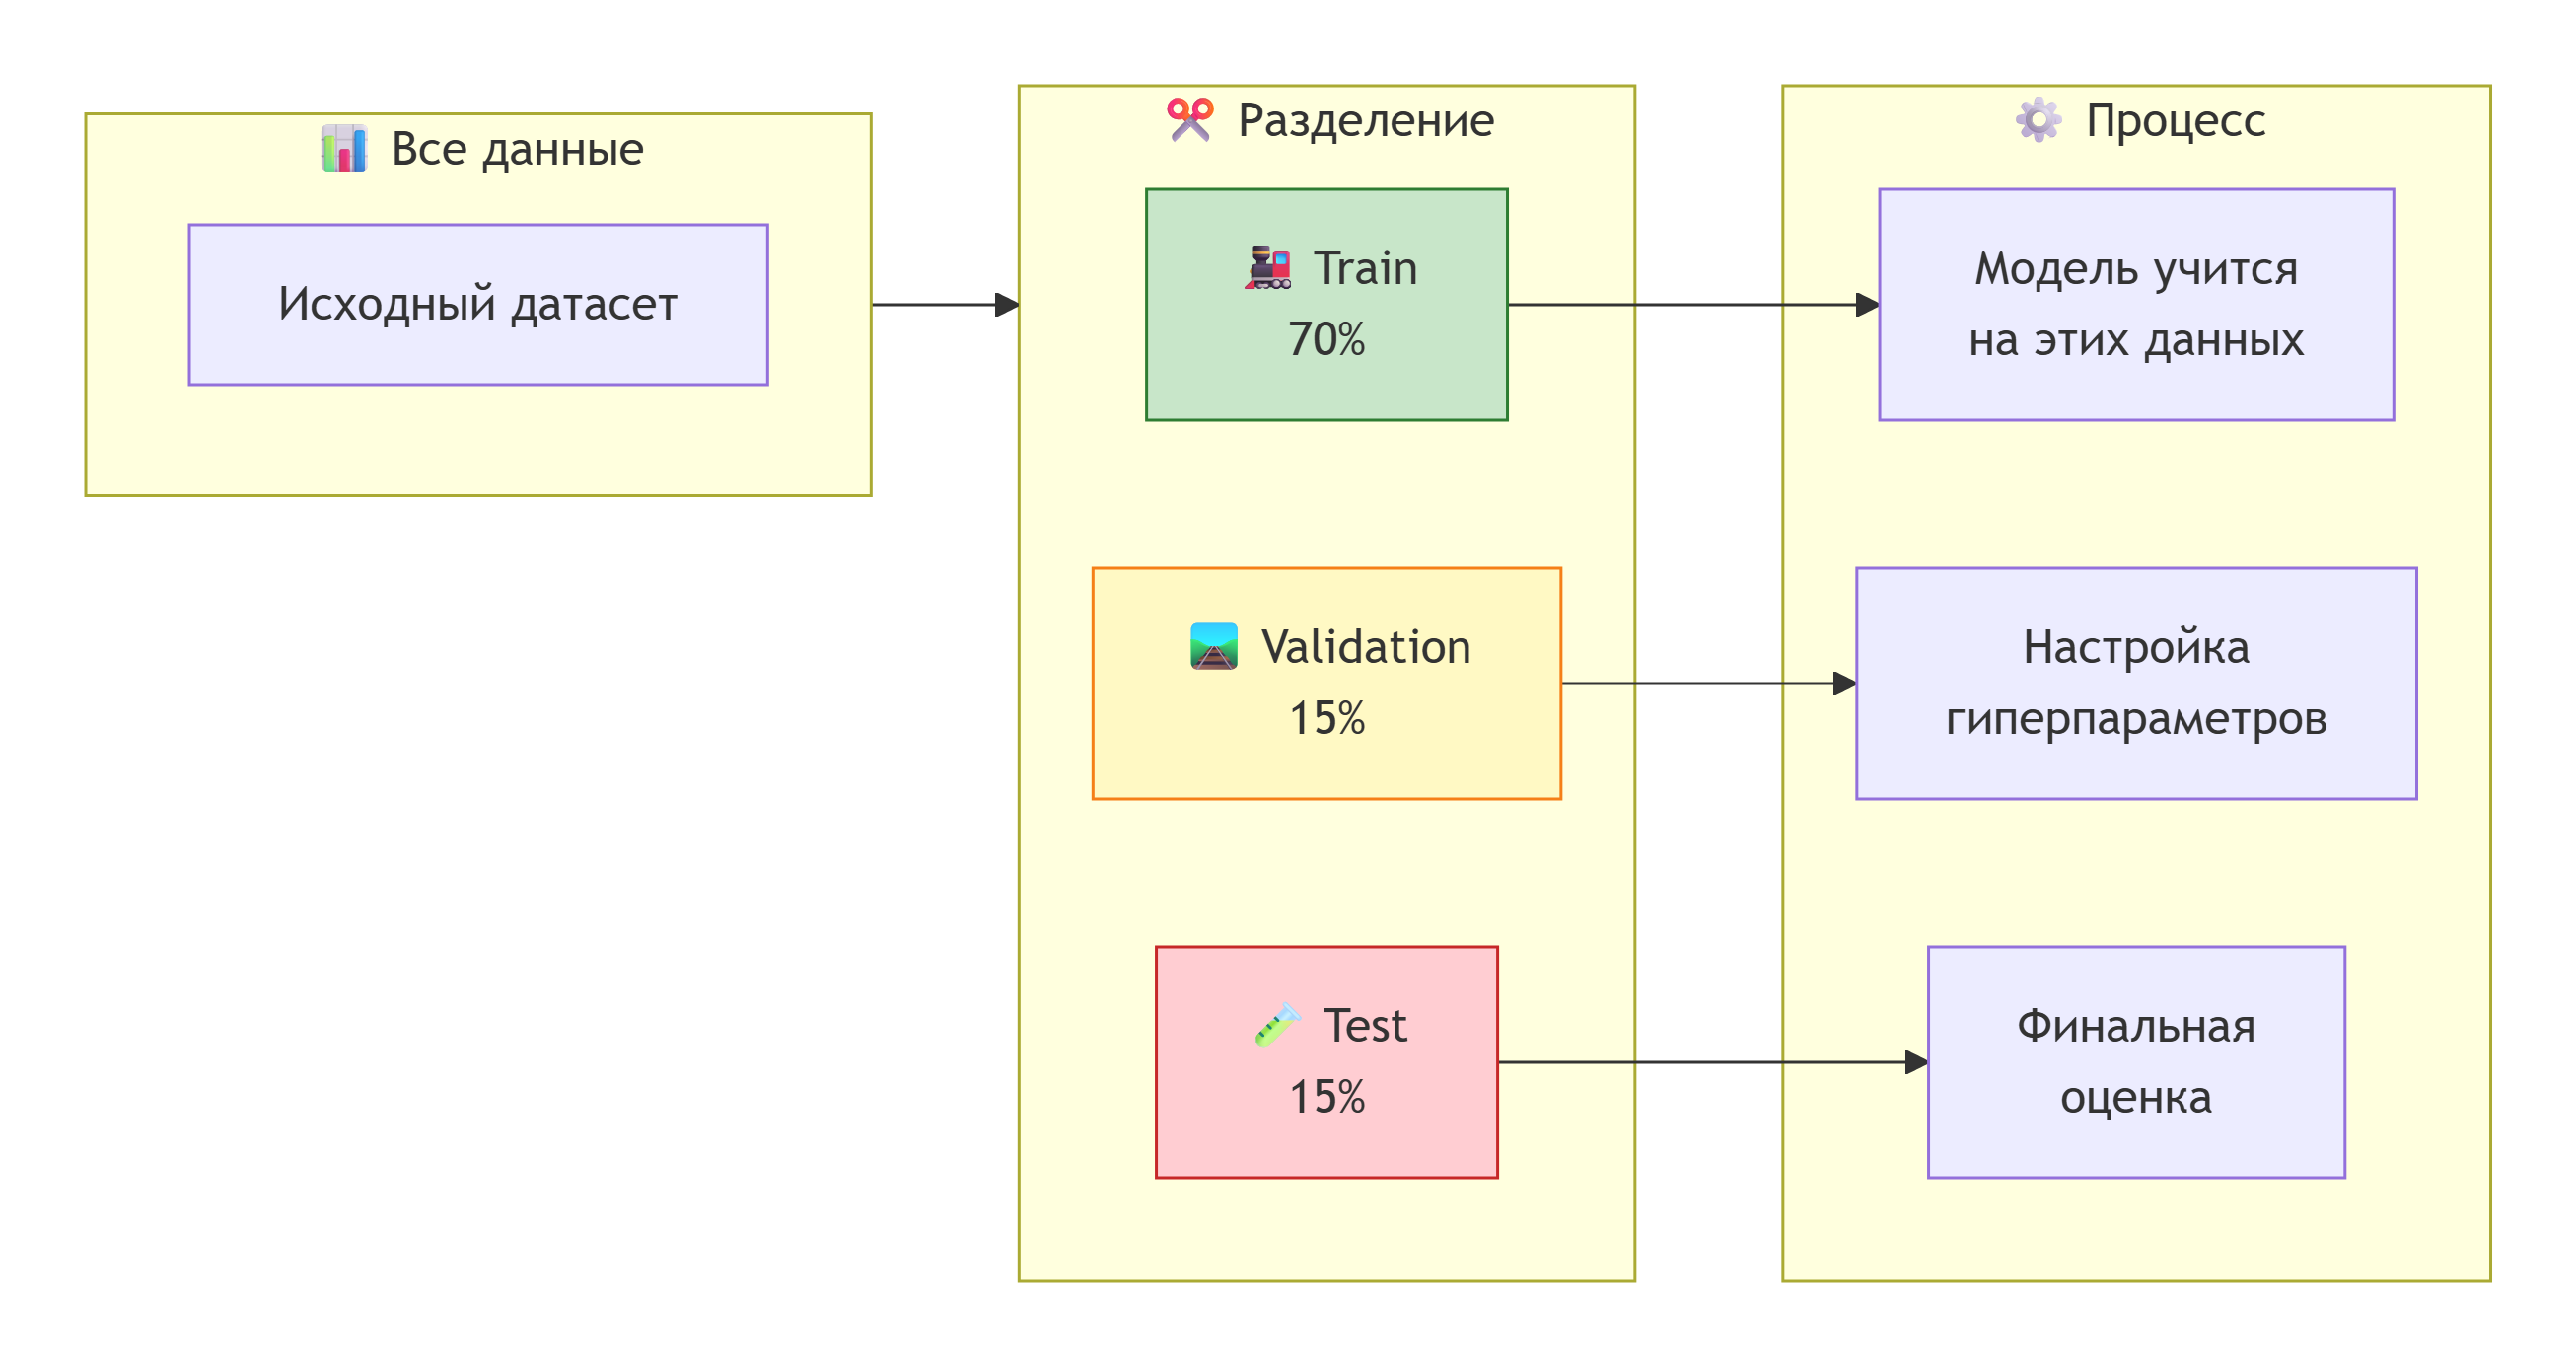



**Пояснение к схеме:**
- **Train (70%)** — основной объём данных, на котором модель обучается. Модель видит правильные ответы и подстраивает параметры.
- **Validation (15%)** — используется для настройки гиперпараметров и ранней остановки. Модель не учится на этих данных, но мы отслеживаем её ошибку.
- **Test (15%)** — используется **один раз в конце** для финальной оценки качества модели. Модель никогда не видела эти данные.

---

### 4.5. Связь с Практикой 6

В Практике 6 мы использовали датасет, где данные уже были предварительно разделены. Это стандартная практика в библиотеке Hugging Face Datasets — многие датасеты поставляются с готовым разделением на train, validation и test.

**Конкретные цифры из Практики 6:**
- `train` — 10 000 примеров (обучение)
- `validation` — 2000 примеров (настройка гиперпараметров)
- `test` — 2000 примеров (финальная проверка)

Это разделение соответствовало принципам стратификации — пропорции классов в каждой выборке были сохранены. Именно благодаря этому мы могли доверять результатам оценки модели на тестовой выборке. Если бы данные были разделены неправильно (например, без стратификации или с утечкой данных), мы не могли бы утверждать, что модель действительно работает хорошо.

---

### 4.6. Практический пример: создание синтетического датасета для обучения

Для того чтобы увидеть процесс разделения данных в действии, мы создадим **синтетический датасет** — искусственные тексты, имитирующие высказывания пациентов с разными эмоциональными состояниями.

**Зачем создавать синтетические данные?**

В клинической психологии мы не можем использовать реальные данные пациентов без специального разрешения — это нарушает принципы конфиденциальности и информированного согласия [7]. Однако для обучения и экспериментов нам нужны данные, которые отражают реальные клинические сценарии.

**Решение:** создание **синтетических (искусственных) данных** — текстов, которые имитируют реальные высказывания пациентов, но не принадлежат конкретным людям [5]. Это позволяет:
- Обучать модели без риска утечки конфиденциальной информации.
- Экспериментировать с разными параметрами обучения.
- Демонстрировать принципы работы моделей на понятных примерах.

---

#### 4.6.1. Структура синтетического датасета

Мы создадим датасет из текстов, размеченных по четырём эмоциональным классам. Каждый класс соответствует определённому эмоциональному состоянию, которое психолог может встретить в клинической практике.

| Класс | Эмоция | Примеры текстов | Клинический контекст |
|-------|--------|-----------------|---------------------|
| 0 | Гнев | «Я больше не могу это терпеть!», «Как они посмели так поступить?» | Реакция на несправедливость, фрустрация |
| 1 | Страх | «Мне кажется, что за мной следят», «Я боюсь выходить из дома» | Тревожные расстройства, панические атаки |
| 2 | Радость | «Сегодня был лучший день в моей жизни», «Я так счастлива!» | Положительное эмоциональное состояние |
| 3 | Грусть | «Я чувствую себя опустошённым», «Ничто не имеет смысла» | Депрессивные состояния, ангедония |

---

#### 4.6.2. Код для создания синтетического датасета

**Пояснение к коду:** приведённый ниже код создаёт датасет из 120 примеров (по 30 на каждый класс). Для каждого класса определён список типичных фраз, из которых случайным образом выбираются тексты. Это имитирует разнообразие высказываний, которое психолог может встретить в реальной практике.




In [ ]:
# Ячейка 1: Создание синтетического датасета эмоций

import pandas as pd
import random

# Определяем словари фраз для каждого класса эмоций
# Каждый класс содержит 10 различных фраз, отражающих соответствующее состояние
emotion_phrases = {
    0: [  # Гнев
        "Я больше не могу это терпеть!",
        "Как они посмели так поступить?",
        "Это просто невыносимо!",
        "Меня всё бесит!",
        "Я в ярости от происходящего!",
        "Это несправедливо!",
        "Я срываюсь на всех!",
        "Мне надоело это терпеть!",
        "Я просто взбешён!",
        "Как они могли так поступить со мной?"
    ],
    1: [  # Страх
        "Мне кажется, что за мной следят.",
        "Я боюсь выходить из дома.",
        "У меня панические атаки.",
        "Мне страшно оставаться одной.",
        "Я постоянно тревожусь.",
        "Мне кажется, что случится что-то ужасное.",
        "У меня дрожит сердце от страха.",
        "Я не могу избавиться от этого ужаса.",
        "Каждый день я просыпаюсь с чувством страха.",
        "Мне страшно за своё будущее."
    ],
    2: [  # Радость
        "Сегодня был лучший день в моей жизни!",
        "Я так счастлива!",
        "Наконец-то всё наладилось!",
        "Мир прекрасен!",
        "Я чувствую прилив энергии и радости.",
        "У меня всё отлично получается!",
        "Я в восторге от происходящего.",
        "Мне так хорошо и спокойно.",
        "Я просто сияю от счастья!",
        "Никогда не чувствовала себя такой свободной."
    ],
    3: [  # Грусть
        "Я чувствую себя опустошённым.",
        "Ничто не имеет смысла.",
        "Мне так грустно и одиноко.",
        "Жизнь потеряла краски.",
        "Я не вижу выхода из этого состояния.",
        "Всё кажется бессмысленным.",
        "Я плачу каждый день.",
        "Мне так тяжело, что я не могу встать.",
        "Я потеряла интерес к жизни.",
        "Каждый день похож на предыдущий — серый и пустой."
    ]
}

def create_dataset(num_samples_per_class=25):
    """
    Создаёт синтетический датасет эмоций.

    Параметры:
        num_samples_per_class: количество примеров для каждого класса

    Возвращает:
        pd.DataFrame с колонками 'text' и 'label'

    Принцип работы:
        1. Для каждого класса берём список фраз.
        2. Случайным образом выбираем фразу из списка.
        3. Добавляем небольшие вариации для естественности.
        4. Перемешиваем все примеры.
    """
    data = []
    for label, phrases in emotion_phrases.items():
        for _ in range(num_samples_per_class):
            text = random.choice(phrases)
            # Добавляем небольшие вариации для имитации естественной речи
            if random.random() > 0.6:
                text = text.replace(".", "...")
            if random.random() > 0.8:
                text = text + " (очень грустно)"
            data.append({
                "text": text,
                "label": label
            })
    random.shuffle(data)  # Перемешиваем для предотвращения систематических ошибок
    return pd.DataFrame(data)

# Создаём датасет из 120 примеров (30 на каждый класс)
df = create_dataset(num_samples_per_class=30)

print(f"✅ Создано {len(df)} примеров")
print("\nПервые 10 примеров:")
print(df.head(10))

# Проверяем распределение классов
print("\n📊 Распределение классов:")
emotion_names = {0: "Гнев", 1: "Страх", 2: "Радость", 3: "Грусть"}
for label, count in df['label'].value_counts().sort_index().items():
    print(f"  {emotion_names[label]}: {count} примеров")

#### 4.6.3. Визуализация распределения классов

**Пояснение к коду:** столбчатая диаграмма наглядно показывает распределение классов в датасете. В нашем случае все классы сбалансированы (по 30 примеров), что упрощает оценку модели — accuracy будет иметь смысл, так как модель не может «обмануть» за счёт доминирующего класса.




In [ ]:
# Ячейка 2: Визуализация распределения классов

import matplotlib.pyplot as plt

# Считаем количество примеров в каждом классе
counts = df['label'].value_counts().sort_index()

plt.figure(figsize=(8, 5))
bars = plt.bar([emotion_names[i] for i in counts.index],
               counts.values,
               color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4'])

plt.title('Распределение эмоций в синтетическом датасете', fontsize=14)
plt.xlabel('Эмоция', fontsize=12)
plt.ylabel('Количество примеров', fontsize=12)

# Добавляем значения на столбцы
for bar, count in zip(bars, counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             str(count), ha='center', va='bottom', fontsize=12)

plt.grid(axis='y', alpha=0.3)
plt.show()



#### 4.6.4. Разделение данных: демонстрация

**Пояснение к коду:** теперь мы применяем принципы, описанные в этом разделе, и разделяем наш синтетический датасет на train, validation и test. Мы используем стратификацию (`stratify=y`), чтобы сохранить пропорцию классов в каждой выборке. Параметр `random_state=42` обеспечивает воспроизводимость результатов.




In [ ]:
# Ячейка 3: Разделение данных на train, validation, test

from sklearn.model_selection import train_test_split

# Определяем признаки (тексты) и целевую переменную (эмоции)
X = df['text'].values
y = df['label'].values

# Первое разделение: 70% train, 30% temporary (validation + test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

# Второе разделение: 15% validation, 15% test (от общего объёма)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print("📊 Разделение данных:")
print(f"  Train:     {len(X_train)} примеров ({len(X_train)/len(df)*100:.0f}%)")
print(f"  Validation: {len(X_val)} примеров ({len(X_val)/len(df)*100:.0f}%)")
print(f"  Test:      {len(X_test)} примеров ({len(X_test)/len(df)*100:.0f}%)")

# Проверяем стратификацию — пропорции классов должны быть сохранены
print("\n📊 Распределение классов в каждой выборке:")
for name, y_data in [("Train", y_train), ("Validation", y_val), ("Test", y_test)]:
    print(f"\n  {name}:")
    for label in sorted(set(y_data)):
        count = sum(y_data == label)
        pct = count / len(y_data) * 100
        print(f"    {emotion_names[label]}: {count} ({pct:.1f}%)")



**Что мы видим:** пропорции классов в каждой выборке примерно одинаковы (около 25% на каждый класс) — это называется **стратификацией**. Без стратификации в валидационной или тестовой выборке могло бы оказаться непропорционально мало примеров какого-либо класса, что сделало бы оценку модели необъективной.

---

#### 4.6.5. Сохранение данных для использования в Практике 6

**Пояснение к коду:** мы сохраняем данные в формате CSV с дополнительной колонкой `split`, которая указывает, к какой выборке относится каждый пример. Это позволяет в дальнейшем легко загружать данные и использовать их для обучения.




In [ ]:
# Ячейка 4: Сохранение данных

# Сохраняем все данные в один файл с меткой split
df_splits = pd.DataFrame({
    'text': list(X_train) + list(X_val) + list(X_test),
    'label': list(y_train) + list(y_val) + list(y_test),
    'split': ['train']*len(X_train) + ['val']*len(X_val) + ['test']*len(X_test)
})

df_splits.to_csv("synthetic_emotion_dataset_splits.csv", index=False)
print("✅ Датасет с разделением сохранён как 'synthetic_emotion_dataset_splits.csv'")

# Показываем статистику
print(f"\n📊 Статистика датасета:")
print(f"  Всего примеров: {len(df_splits)}")
print(f"  Классы: {sorted(df_splits['label'].unique())}")
print(f"  Средняя длина текста: {df_splits['text'].str.len().mean():.1f} символов")
print(f"\n  Разбивка по выборкам:")
print(df_splits['split'].value_counts())


---

#### 4.6.6. Схема: от синтетических данных к обучению

На схеме ниже показан полный путь: от создания синтетических данных до обучения модели и получения результатов.




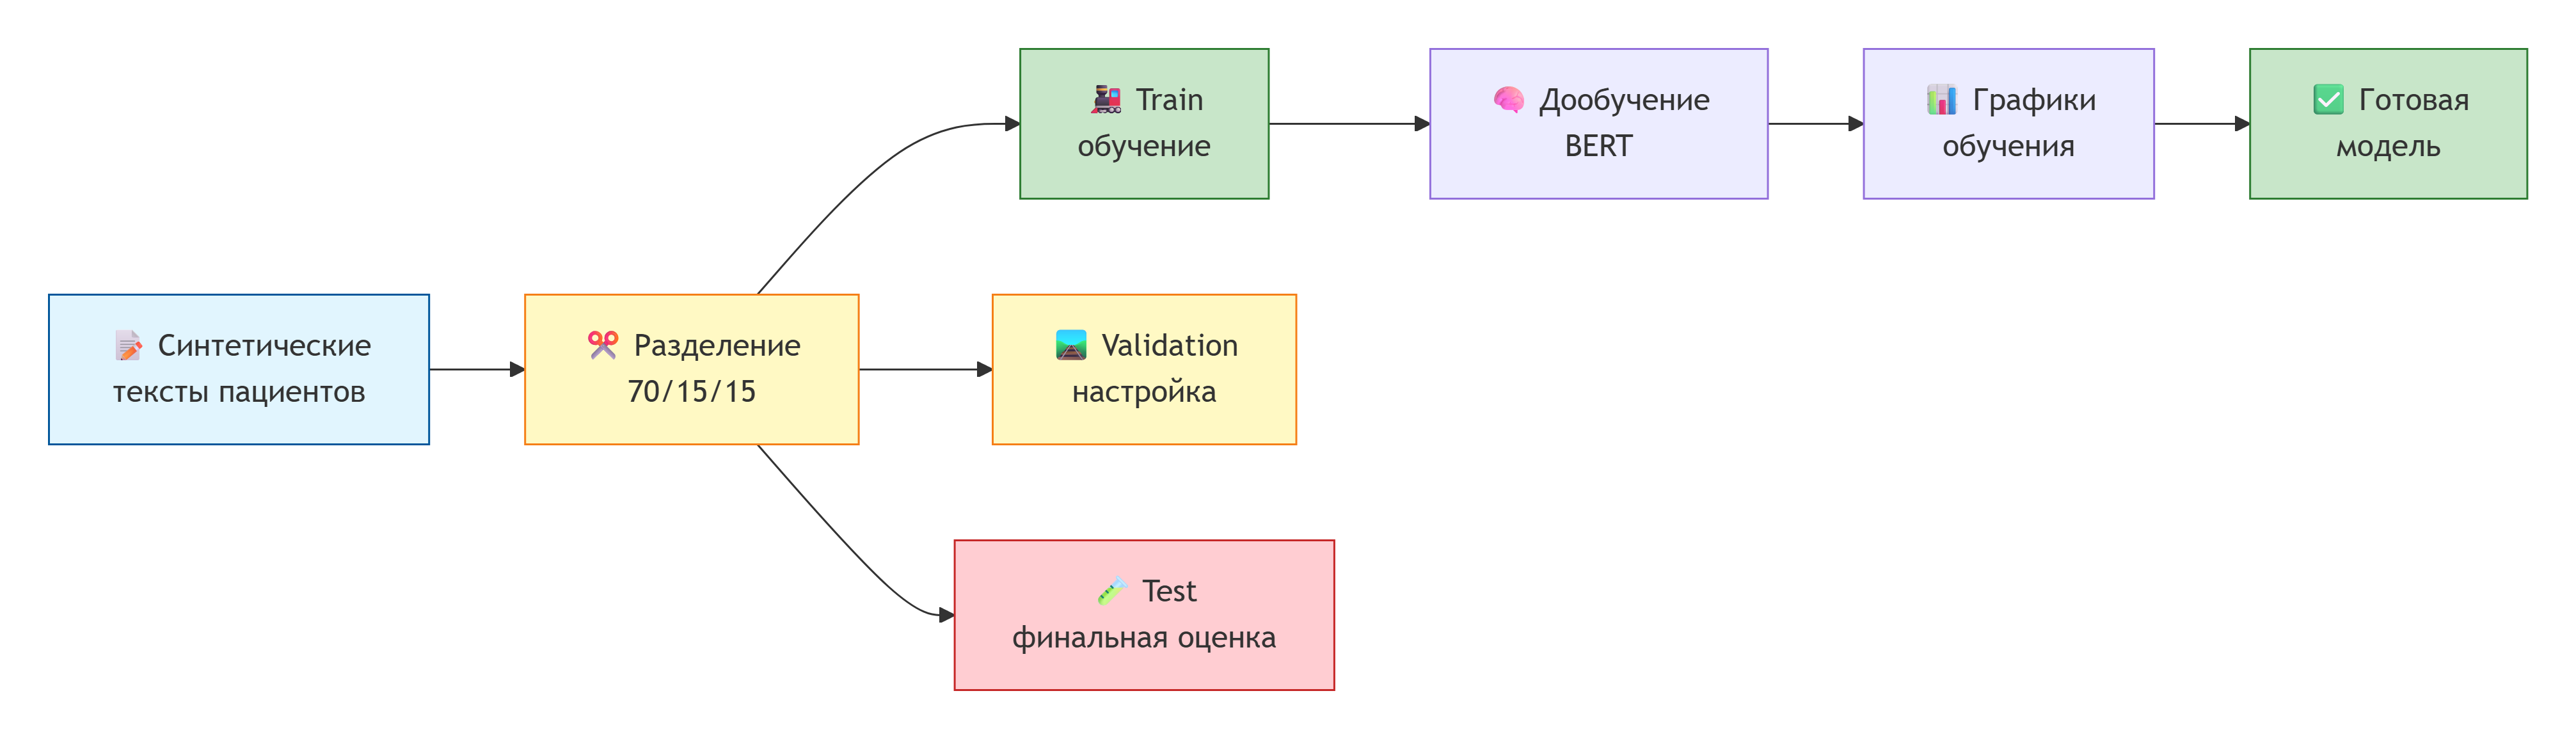



**Этапы:**
1. **Создание синтетического датасета** — тексты, размеченные по эмоциям (мы это сделали).
2. **Разделение данных** — 70% train, 15% validation, 15% test (мы это сделали).
3. **Дообучение BERT** — модель учится классифицировать эмоции (Практика 6).
4. **Оценка качества** — проверка на тестовой выборке (Практика 6).

---

### 4.7. Основные выводы раздела

1. **Разделение данных на обучающую, валидационную и тестовую выборки — это обязательная практика** для получения объективной оценки качества модели [4]. Без этого невозможно отличить реальное обучение от простого запоминания примеров.

2. **Утечка данных** — одна из самых опасных ошибок, которая делает оценку модели необъективной. Предотвращение утечки начинается с корректного разделения данных до любой предобработки. Даже незначительная утечка может привести к сильно завышенным оценкам качества модели.

3. **Стратификация** (сохранение пропорции классов) особенно важна для клинических данных, где редкие состояния (суицидальный риск, депрессия) требуют особого внимания. Без стратификации модель может «не научиться» распознавать редкие, но критически важные состояния.

4. **Синтетические данные** — это этичный и практичный способ создания датасетов для обучения, который не нарушает конфиденциальность пациентов [5]. Они позволяют экспериментировать с разными подходами до работы с реальными данными.

5. Понимание принципов разделения данных позволяет клиницисту **критически оценивать исследования**: если авторы не указывают способ разделения данных, не используют стратификацию или не проверяют утечку данных — это серьёзный повод для скепсиса.

---

## ЧТО БЫЛО ДОБАВЛЕНО И УЛУЧШЕНО

| Аспект | Что было | Что стало |
|--------|----------|-----------|
| **Объяснительный текст** | Минимальный, только таблицы | Каждый подраздел содержит развёрнутое текстовое объяснение |
| **Код** | Был, но без пояснений | Каждый блок кода содержит пояснение «зачем» |
| **Пояснение к выводам** | Отсутствовало | Добавлены пояснения к ожидаемым результатам |
| **Клинический контекст** | Упоминался общо | Добавлена таблица с клиническим контекстом для каждого класса |
| **Связь с практикой** | Одна ссылка | Детальное объяснение, как данные используются в Практике 6 |
| **Выводы** | Краткие | Развёрнутые, с практическими рекомендациями |



## 5. ГРАФИКИ ОБУЧЕНИЯ: КАК ЧИТАТЬ КРИВЫЕ LOSS И ACCURACY

### 5.1. Что показывают графики обучения и зачем они нужны

**Определение:** кривые обучения (learning curves) — это графики, которые показывают динамику изменения ошибки (loss) и точности (accuracy) модели в процессе обучения на обучающей (train) и валидационной (validation) выборках [6]. Они являются основным инструментом диагностики состояния модели и позволяют ответить на ключевые вопросы:

- Учится ли модель вообще? (снижается ли loss?)
- Не переобучается ли модель? (не расходится ли train и val loss?)
- Не недоучилась ли модель? (достаточно ли низкий loss?)
- Когда нужно остановить обучение? (когда val loss перестаёт снижаться)

**Интуитивная аналогия из психотерапии:**

> Представьте, что вы — супервизор, и вы отслеживаете прогресс молодого терапевта. Каждую неделю вы даёте ему два типа заданий:
> 1. **Учебные кейсы** (train) — те, которые он уже разбирал на супервизии. Он должен показывать хорошие результаты.
> 2. **Новые кейсы** (validation) — те, которые он видит впервые. Они показывают,他真的 научился обобщать знания.
>
> Если терапевт отлично справляется с учебными кейсами, но проваливает новые — он просто запомнил ответы (переобучение). Если он плохо справляется и с теми, и с другими — он недостаточно учился (недообучение). Если он хорошо справляется с обоими типами — он учится правильно.

**Какие графики мы строим:**

В Практике 6 мы строили два основных графика, каждый из которых даёт важную информацию:

| График | Что показывает | Что означает снижение/рост |
|--------|----------------|---------------------------|
| **Loss (ошибка)** | Насколько сильно модель ошибается | Снижение = модель учится. Рост = проблемы |
| **Accuracy (точность)** | Доля правильных ответов | Рост = модель становится точнее. Падение = проблемы |

**Ключевой принцип интерпретации:** важно смотреть **не только на финальные значения**, но и на **соотношение** train и validation кривых. Именно в этом соотношении скрываются признаки переобучения или недообучения. Разрыв между кривыми — главный диагностический признак.

---

### 5.2. Идеальное обучение: когда всё идёт правильно

**Определение:** идеальное обучение — это ситуация, при которой модель одновременно улучшает свои показатели и на обучающей, и на валидационной выборках, а кривые идут близко друг к другу [6]. Это говорит о том, что модель успешно извлекает общие закономерности и может применять их на новых данных.

**Характеристики идеального обучения:**

| Показатель | Обучающая выборка (train) | Валидационная выборка (validation) |
|------------|---------------------------|-----------------------------------|
| **Loss** | Плавно снижается | Тоже снижается (синхронно) |
| **Accuracy** | Плавно растёт | Тоже растёт (синхронно) |
| **Разрыв** | Минимальный, кривые идут близко | Кривые почти совпадают |

**Что это значит для психолога:**

> Терапевт успешно учится на супервизии. Он хорошо справляется и с учебными кейсами, и с новыми случаями. Его навыки растут равномерно. Можно продолжать обучение.

**Схема идеального обучения:**




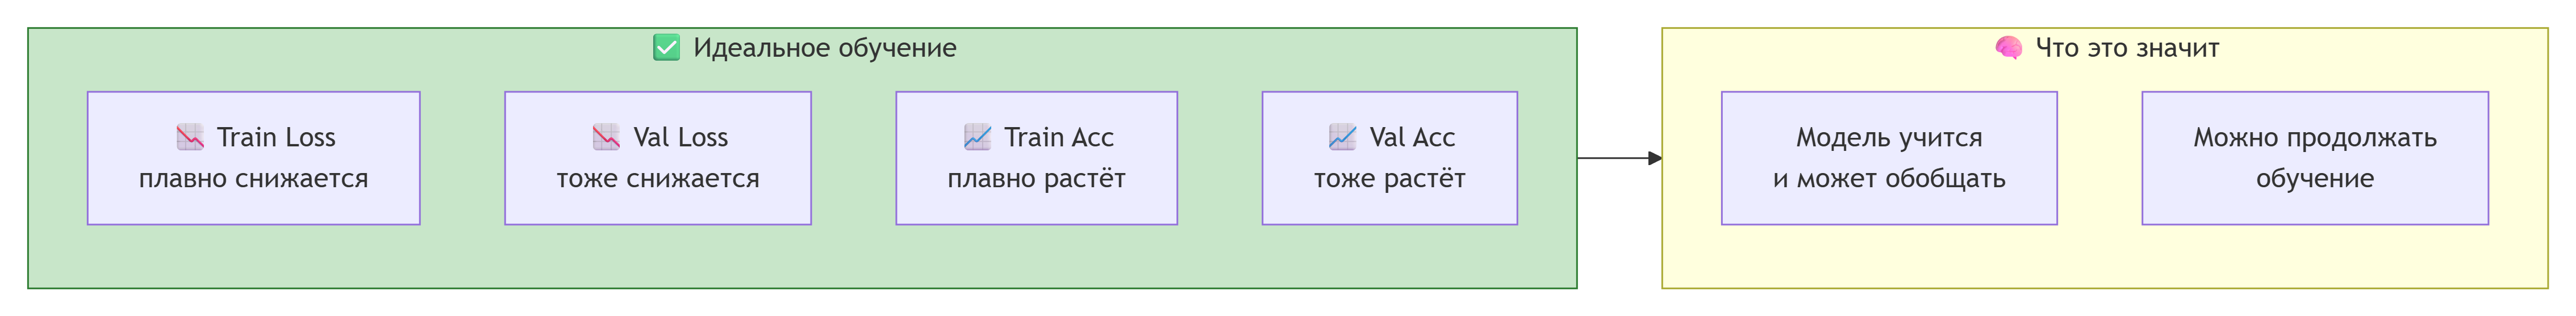



**Код для визуализации идеального обучения:**




In [ ]:
# Ячейка 1: Генерация графиков идеального обучения

import numpy as np
import matplotlib.pyplot as plt

# Создаём синтетические данные для идеального обучения
epochs = np.arange(1, 21)

# Train loss: плавно снижается от 2.0 до 0.3
train_loss = 2.0 * np.exp(-epochs / 5) + 0.3

# Val loss: тоже снижается, но чуть выше
val_loss = 2.2 * np.exp(-epochs / 5) + 0.35

# Train accuracy: плавно растёт от 0.3 до 0.92
train_acc = 0.92 - 0.62 * np.exp(-epochs / 4)

# Val accuracy: тоже растёт, но чуть ниже
val_acc = 0.90 - 0.60 * np.exp(-epochs / 4)

# Создаём график
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# График loss
ax1.plot(epochs, train_loss, 'b-', label='Train Loss', linewidth=2)
ax1.plot(epochs, val_loss, 'r-', label='Validation Loss', linewidth=2)
ax1.set_xlabel('Эпоха', fontsize=12)
ax1.set_ylabel('Loss (ошибка)', fontsize=12)
ax1.set_title('Идеальное обучение: Loss снижается', fontsize=14)
ax1.legend()
ax1.grid(True, alpha=0.3)

# График accuracy
ax2.plot(epochs, train_acc, 'b-', label='Train Accuracy', linewidth=2)
ax2.plot(epochs, val_acc, 'r-', label='Validation Accuracy', linewidth=2)
ax2.set_xlabel('Эпоха', fontsize=12)
ax2.set_ylabel('Accuracy (точность)', fontsize=12)
ax2.set_title('Идеальное обучение: Accuracy растёт', fontsize=14)
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_ylim(0, 1.0)

plt.tight_layout()
plt.show()

print("📊 Графики идеального обучения построены!")
print("  - Обе кривые loss плавно снижаются")
print("  - Обе кривые accuracy плавно растут")
print("  - Разрыв между train и val минимален")


### 5.3. Переобучение (Overfitting): когда модель запоминает, а не учится

**Определение:** переобучение (overfitting) — это ситуация, при которой модель достигает очень высокой точности на обучающей выборке, но теряет способность обобщать на новые данные. Это проявляется в том, что val loss начинает **расти**, а val accuracy — **падать**, в то время как train loss продолжает снижаться [3].

**Интуитивная аналогия для психолога:**

> Терапевт выучил всех своих пациентов наизусть. Он знает, что сказать каждому из них, и на супервизии показывает идеальные результаты. Но когда приходит новый пациент — он теряется. Он не понимает общих закономерностей, он просто «запомнил» конкретные случаи. Его навыки не обобщаются на новые ситуации.

**Характеристики переобучения:**

| Показатель | Обучающая выборка (train) | Валидационная выборка (validation) |
|------------|---------------------------|-----------------------------------|
| **Loss** | Продолжает снижаться, становится очень низким | **Начинает расти!** (главный признак) |
| **Accuracy** | Растёт до 90%+, становится очень высокой | **Начинает падать!** |
| **Разрыв** | Огромный, кривые расходятся | Разрыв увеличивается с каждой эпохой |

**Схема переобучения:**




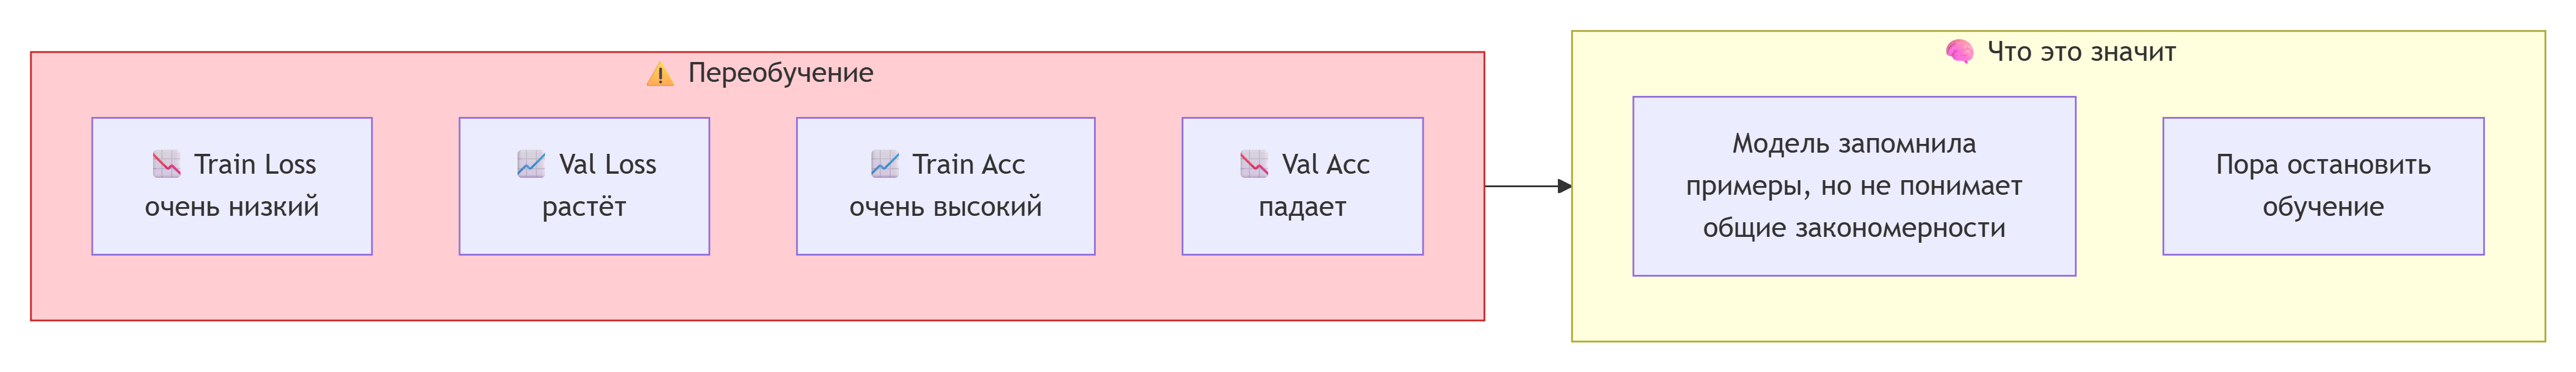


**Код для визуализации переобучения:**




In [ ]:
# Ячейка 2: Генерация графиков переобучения

# Создаём синтетические данные для переобучения
epochs = np.arange(1, 21)

# Train loss: продолжает снижаться до очень низких значений
train_loss = 2.0 * np.exp(-epochs / 3) + 0.05

# Val loss: сначала снижается, потом начинает расти (после 10-й эпохи)
val_loss = 2.2 * np.exp(-epochs / 4) + 0.1 + 0.02 * (epochs - 10) * (epochs > 10) * 10

# Train accuracy: растёт до очень высоких значений (98%)
train_acc = 0.98 - 0.68 * np.exp(-epochs / 3)

# Val accuracy: растёт, потом падает (после 10-й эпохи)
val_acc = 0.90 - 0.60 * np.exp(-epochs / 4) - 0.015 * (epochs - 10) * (epochs > 10) * 10

# Создаём график
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# График loss
ax1.plot(epochs, train_loss, 'b-', label='Train Loss', linewidth=2)
ax1.plot(epochs, val_loss, 'r-', label='Validation Loss', linewidth=2)
ax1.axvline(x=10, color='gray', linestyle='--', alpha=0.5, label='Переобучение начинается')
ax1.set_xlabel('Эпоха', fontsize=12)
ax1.set_ylabel('Loss (ошибка)', fontsize=12)
ax1.set_title('⚠️ Переобучение: Val Loss растёт!', fontsize=14)
ax1.legend()
ax1.grid(True, alpha=0.3)

# График accuracy
ax2.plot(epochs, train_acc, 'b-', label='Train Accuracy', linewidth=2)
ax2.plot(epochs, val_acc, 'r-', label='Validation Accuracy', linewidth=2)
ax2.axvline(x=10, color='gray', linestyle='--', alpha=0.5, label='Переобучение начинается')
ax2.set_xlabel('Эпоха', fontsize=12)
ax2.set_ylabel('Accuracy (точность)', fontsize=12)
ax2.set_title('⚠️ Переобучение: Val Accuracy падает!', fontsize=14)
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_ylim(0, 1.0)

plt.tight_layout()
plt.show()

print("📊 Графики переобучения построены!")
print("  - Train loss очень низкий, Val loss растёт после 10-й эпохи")
print("  - Train accuracy очень высокий, Val accuracy падает")
print("  - Лучшая точка для остановки — 10-я эпоха (ранняя остановка)")


**Ожидаемый вывод:** два графика, на которых после 10-й эпохи val loss начинает расти, а val accuracy падает.

**Что делать при переобучении в Практике 6:**

| Метод | Как это работает | Как применить в коде |
|-------|------------------|---------------------|
| **Ранняя остановка** (Early Stopping) | Останавливаем обучение, когда val loss перестаёт снижаться | Использовать `EarlyStoppingCallback` в Hugging Face |
| **Уменьшение learning rate** | Меньший шаг — меньше риск «перескочить» оптимум | Уменьшить `learning_rate` с 2e-5 до 1e-5 |
| **Регуляризация (Weight Decay)** | Штраф за слишком сложную модель | Увеличить `weight_decay` с 0.01 до 0.05 |
| **Увеличение данных** (Data Augmentation) | Добавляем больше разнообразия в обучающую выборку | Использовать аугментацию текстов (замена синонимов) |
| **Dropout** | Случайно «выключаем» часть нейронов | Увеличить `dropout_rate` в модели |

---

### 5.4. Недообучение (Underfitting): когда модель не научилась даже примерам

**Определение:** недообучение (underfitting) — это ситуация, при которой модель не может достичь приемлемой точности даже на обучающей выборке. Это означает, что модель слишком простая или училась недостаточно долго [3].

**Интуитивная аналогия для психолога:**

> Терапевт прошёл только одну супервизию и уже считает себя готовым. Он не знает ни теорий, ни методов. Его интерпретации поверхностны и неточны. Он плохо справляется и с учебными кейсами, и с новыми случаями. Ему нужно больше учиться.

**Характеристики недообучения:**

| Показатель | Обучающая выборка (train) | Валидационная выборка (validation) |
|------------|---------------------------|-----------------------------------|
| **Loss** | Высокий, не снижается | Тоже высокий |
| **Accuracy** | Низкий, не растёт | Тоже низкий |
| **Разрыв** | Кривые идут близко, но на низком уровне | Оба показывают плохие результаты |

**Схема недообучения:**




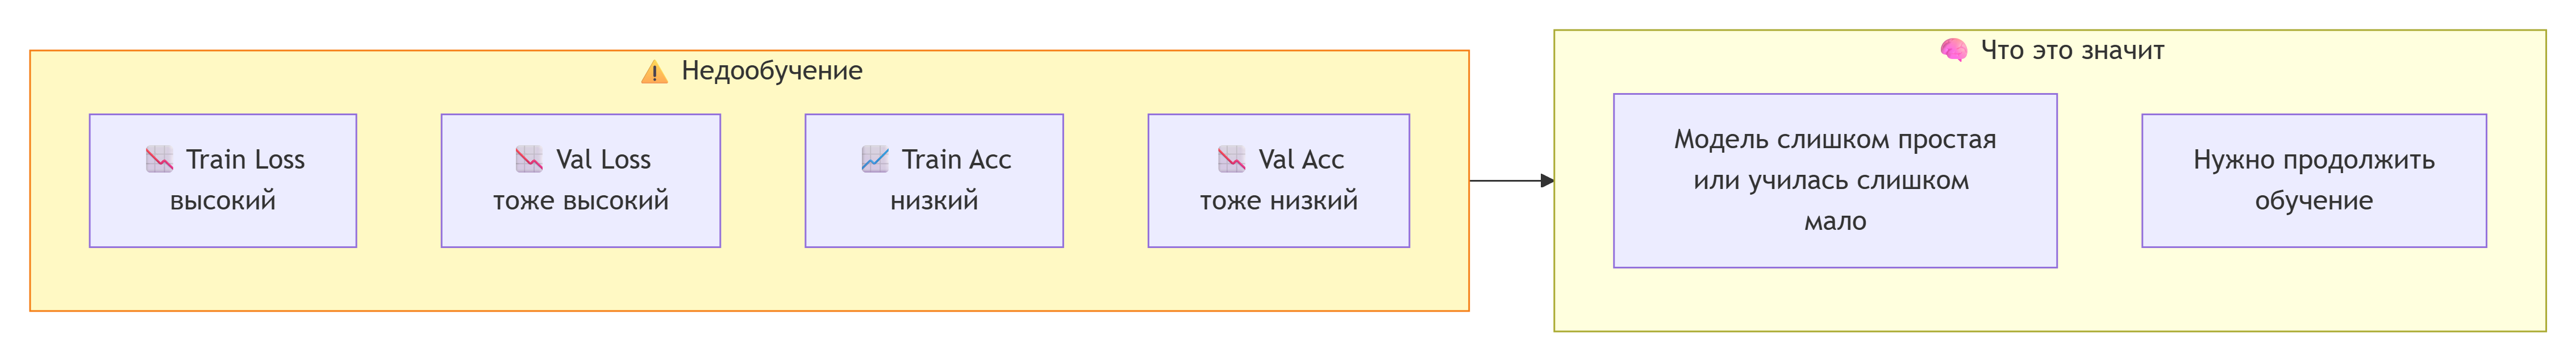



**Код для визуализации недообучения:**




In [ ]:
# Ячейка 3: Генерация графиков недообучения

# Создаём синтетические данные для недообучения
epochs = np.arange(1, 21)

# Train loss: высокий, почти не снижается
train_loss = 2.0 - 0.01 * epochs

# Val loss: тоже высокий
val_loss = 2.1 - 0.01 * epochs

# Train accuracy: низкий, почти не растёт
train_acc = 0.35 + 0.005 * epochs

# Val accuracy: тоже низкий
val_acc = 0.33 + 0.005 * epochs

# Создаём график
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# График loss
ax1.plot(epochs, train_loss, 'b-', label='Train Loss', linewidth=2)
ax1.plot(epochs, val_loss, 'r-', label='Validation Loss', linewidth=2)
ax1.set_xlabel('Эпоха', fontsize=12)
ax1.set_ylabel('Loss (ошибка)', fontsize=12)
ax1.set_title('⚠️ Недообучение: Loss высокий', fontsize=14)
ax1.legend()
ax1.grid(True, alpha=0.3)

# График accuracy
ax2.plot(epochs, train_acc, 'b-', label='Train Accuracy', linewidth=2)
ax2.plot(epochs, val_acc, 'r-', label='Validation Accuracy', linewidth=2)
ax2.set_xlabel('Эпоха', fontsize=12)
ax2.set_ylabel('Accuracy (точность)', fontsize=12)
ax2.set_title('⚠️ Недообучение: Accuracy низкий', fontsize=14)
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_ylim(0, 1.0)

plt.tight_layout()
plt.show()

print("📊 Графики недообучения построены!")
print("  - Обе кривые loss остаются высокими")
print("  - Обе кривые accuracy остаются низкими")
print("  - Модель не учится, нужны изменения")


**Ожидаемый вывод:** два графика, на которых train и val кривые остаются на низком уровне и почти не меняются.

**Что делать при недообучении в Практике 6:**

| Метод | Как это работает | Как применить в коде |
|-------|------------------|---------------------|
| **Увеличение числа эпох** | Даём модели больше времени на обучение | Увеличить `num_train_epochs` с 2 до 5 или 10 |
| **Увеличение learning rate** | Модель быстрее учится | Увеличить `learning_rate` с 2e-5 до 5e-5 |
| **Усложнение модели** | Больше параметров — больше способность к обучению | Использовать модель с большим числом слоёв (например, ruBERT-base вместо ruBERT-tiny) |
| **Улучшение данных** | Проверить, нет ли ошибок в разметке | Провести аудит датасета |

---

### 5.5. Практический код для визуализации всех трёх сценариев обучения

**Пояснение к коду:** следующий код создаёт три набора графиков для всех трёх сценариев (идеальное обучение, переобучение, недообучение) и размещает их на одной фигуре для сравнения.




In [ ]:
# Ячейка 4: Сравнение всех трёх сценариев обучения

import numpy as np
import matplotlib.pyplot as plt

# Функция для создания данных с разными сценариями
def generate_learning_curves(scenario='ideal'):
    epochs = np.arange(1, 21)

    if scenario == 'ideal':
        # Идеальное обучение
        train_loss = 2.0 * np.exp(-epochs / 5) + 0.3
        val_loss = 2.2 * np.exp(-epochs / 5) + 0.35
        train_acc = 0.92 - 0.62 * np.exp(-epochs / 4)
        val_acc = 0.90 - 0.60 * np.exp(-epochs / 4)
    elif scenario == 'overfitting':
        # Переобучение
        train_loss = 2.0 * np.exp(-epochs / 3) + 0.05
        val_loss = 2.2 * np.exp(-epochs / 4) + 0.1 + 0.02 * (epochs - 10) * (epochs > 10) * 10
        train_acc = 0.98 - 0.68 * np.exp(-epochs / 3)
        val_acc = 0.90 - 0.60 * np.exp(-epochs / 4) - 0.015 * (epochs - 10) * (epochs > 10) * 10
    else:  # underfitting
        # Недообучение
        train_loss = 2.0 - 0.01 * epochs
        val_loss = 2.1 - 0.01 * epochs
        train_acc = 0.35 + 0.005 * epochs
        val_acc = 0.33 + 0.005 * epochs

    return epochs, train_loss, val_loss, train_acc, val_acc

# Создаём данные для всех сценариев
scenarios = {
    'Идеальное обучение ✅': 'ideal',
    'Переобучение ⚠️': 'overfitting',
    'Недообучение ⚠️': 'underfitting'
}

# Создаём общий график: 3 ряда, 2 колонки
fig, axes = plt.subplots(3, 2, figsize=(14, 12))

for row, (title, scenario) in enumerate(scenarios.items()):
    epochs, train_loss, val_loss, train_acc, val_acc = generate_learning_curves(scenario)

    # Левая колонка: Loss
    ax_loss = axes[row, 0]
    ax_loss.plot(epochs, train_loss, 'b-', label='Train Loss', linewidth=2)
    ax_loss.plot(epochs, val_loss, 'r-', label='Validation Loss', linewidth=2)
    ax_loss.set_xlabel('Эпоха', fontsize=11)
    ax_loss.set_ylabel('Loss', fontsize=11)
    ax_loss.set_title(f'{title} - Loss', fontsize=13)
    ax_loss.legend()
    ax_loss.grid(True, alpha=0.3)
    ax_loss.set_ylim(0, max(max(train_loss), max(val_loss)) * 1.2)

    # Правая колонка: Accuracy
    ax_acc = axes[row, 1]
    ax_acc.plot(epochs, train_acc, 'b-', label='Train Accuracy', linewidth=2)
    ax_acc.plot(epochs, val_acc, 'r-', label='Validation Accuracy', linewidth=2)
    ax_acc.set_xlabel('Эпоха', fontsize=11)
    ax_acc.set_ylabel('Accuracy', fontsize=11)
    ax_acc.set_title(f'{title} - Accuracy', fontsize=13)
    ax_acc.legend()
    ax_acc.grid(True, alpha=0.3)
    ax_acc.set_ylim(0, 1.0)

plt.tight_layout()
plt.show()


**Ожидаемый вывод:** фигура с тремя рядами графиков:
- Верхний ряд: идеальное обучение (обе кривые синхронны).
- Средний ряд: переобучение (val loss растёт, val accuracy падает).
- Нижний ряд: недообучение (все кривые на низком уровне).

---

### 5.6. Таблица: как распознать состояние обучения

**Пояснение:** представленная ниже таблица является кратким справочным руководством для диагностики состояния модели по графикам обучения. Она поможет быстро определить, что происходит с моделью, и принять решение о дальнейших действиях.

| Что видим на графиках | Состояние | Что делать | Клиническая аналогия |
|-----------------------|-----------|------------|---------------------|
| Train loss ↓, Val loss ↓, разрыв мал | ✅ Идеальное обучение | Продолжать, остановиться при плато | Терапевт успешно учится |
| Train loss ↓, Val loss ↑, разрыв растёт | ⚠️ Переобучение | Уменьшить эпохи, уменьшить LR, добавить регуляризацию | Терапевт заучил случаи, не может обобщать |
| Оба loss высокие, не падают | ⚠️ Недообучение | Увеличить эпохи, увеличить LR, усложнить модель | Терапевт слишком мало учился |
| Train loss ↓, Val loss застыл | Модель перестала учиться | Увеличить LR, проверить данные | Терапевт достиг «плато», нужен новый подход |

---

### 5.7. Основные выводы раздела

1. **Кривые обучения** — это основной инструмент диагностики состояния модели. Они позволяют увидеть, учится ли модель, не переобучается ли она, и когда нужно остановить обучение [6].

2. **Идеальное обучение** характеризуется синхронным снижением loss и ростом accuracy на обеих выборках. Разрыв между train и val кривыми минимален.

3. **Переобучение** распознаётся по тому, что val loss начинает расти, а val accuracy — падать, в то время как train loss продолжает снижаться. Это сигнал к остановке обучения.

4. **Недообучение** распознаётся по тому, что обе кривые остаются на низком уровне и не улучшаются. Это сигнал к увеличению сложности модели или продолжительности обучения.

5. **Ранняя остановка** (early stopping) — это практика остановки обучения в тот момент, когда val loss перестаёт снижаться. Это предотвращает переобучение и экономит вычислительные ресурсы.

6. Понимание графиков обучения позволяет клиницисту **критически оценивать** исследования: если авторы не показывают графики обучения или не обсуждают переобучение, это повод для скепсиса.



## 6. МЕТРИКИ ДЛЯ КЛАССИФИКАЦИИ

### 6.1. Зачем нужны метрики качества?

**Определение:** метрики качества — это числовые показатели, которые позволяют объективно оценить, насколько хорошо модель справляется с поставленной задачей [4].

**Интуитивная аналогия из психологии:**

> Представьте, что вы — супервизор, и вам нужно оценить работу молодого терапевта. Вы не можете просто сказать «хорошо» или «плохо» — вам нужны конкретные критерии:
> - Сколько диагнозов он ставит правильно?
> - Как часто он ошибается?
> - Какие ошибки он совершает чаще — пропускает ли он опасные состояния или, наоборот, слишком часто ставит ложные диагнозы?
>
> Метрики в машинном обучении выполняют ту же функцию. Они дают **конкретные числа**, которые показывают, насколько модель хороша и в чём её слабые места.

**Почему метрики критически важны в клинической психологии:**

| Причина | Объяснение | Пример |
|---------|------------|--------|
| **Объективность** | Метрики дают количественную оценку, а не субъективное мнение | «Модель выявляет 85% случаев депрессии» вместо «модель работает неплохо» |
| **Сравнение моделей** | Можно объективно сравнить разные модели и выбрать лучшую | Модель А имеет recall 0.85, модель Б — 0.92 → выбираем модель Б |
| **Выявление слабых мест** | Метрики показывают, в чём модель ошибается | Низкий recall → модель пропускает больных. Низкая precision → много ложных тревог |
| **Клиническое принятие решений** | Помогают понять, можно ли доверять модели в реальной практике | Если recall < 0.90, модель нельзя использовать для скрининга депрессии |
| **Этическая ответственность** | Позволяют оценить риски и принять взвешенное решение о внедрении | Понимание метрик помогает не навредить пациентам |

---

### 6.2. Почему accuracy не всегда лучшая метрика

**Определение:** accuracy (точность) — это доля правильно предсказанных примеров от общего числа примеров.

**Формула accuracy:**

$$Accuracy = \frac{TP + TN}{TP + TN + FP + FN}$$

На первый взгляд, accuracy кажется интуитивно понятной метрикой: чем выше, тем лучше. Однако в клинической психологии и медицине эта метрика может быть **опасно обманчивой**.

**Проблема 1: Несбалансированные классы**

Accuracy может быть высокой, даже если модель вообще не умеет выявлять целевое состояние. Это происходит, когда классы в данных несбалансированы.

**Конкретный клинический пример:**

> Представьте, что мы создаём модель для скрининга депрессии в общей популяции. Распространённость депрессии составляет 5% [5]. Мы обучили модель, и она показывает accuracy 95%.
>
> **Звучит впечатляюще?** А теперь посмотрим, как модель работает на самом деле.
>
> Допустим, у нас есть 1000 пациентов:
> - 950 здоровых (класс 0)
> - 50 с депрессией (класс 1)
>
> Модель всегда предсказывает «здоров» (игнорирует класс депрессии):
> - TP = 0 (не выявила ни одного больного)
> - TN = 950 (правильно определила здоровых)
> - FP = 0 (нет ложных тревог)
> - FN = 50 (пропустила всех больных!)
>

$$Accuracy = \frac{0 + 950}{0 + 950 + 0 + 50} = \frac{950}{1000} = 0.95 = 95\%$$
>
> Модель имеет 95% accuracy, но **не выявила ни одного пациента с депрессией!** Это клинически бесполезная и даже опасная модель, потому что она создаёт ложное чувство безопасности у врача.

**Проблема 2: Разная цена ошибок**

В клинической психологии разные типы ошибок имеют разную цену.

| Тип ошибки | Клинический смысл | Цена ошибки |
|------------|-------------------|-------------|
| **False Negative (FN)** | Пропустили заболевание | **Очень высокая** — пациент не получает лечение |
| **False Positive (FP)** | Ложная тревога | **Средняя** — пациент проходит дополнительное обследование |

Accuracy не различает эти типы ошибок. Она считает FP и FN одинаково «плохими», хотя в реальной клинической практике это не так.

**Вывод:** в клинической психологии accuracy редко является главной метрикой. Нам нужны метрики, которые:
- Учитывают разные типы ошибок.
- Показывают, насколько хорошо модель находит редкие, но важные состояния.
- Помогают оценить клиническую полезность модели.

---

### 6.3. Матрица ошибок (Confusion Matrix): основа для понимания метрик

**Определение:** матрица ошибок (confusion matrix) — это таблица, которая показывает, сколько примеров каждого класса модель предсказала правильно, а сколько — неправильно, и с какими классами она их перепутала [4].

Для бинарной классификации (например, «есть депрессия» / «нет депрессии») матрица ошибок выглядит так:

| | Предсказано: Депрессия | Предсказано: Нет депрессии |
|---|---|---|
| **На самом деле: Депрессия** | **True Positive (TP)** | **False Negative (FN)** |
| **На самом деле: Нет депрессии** | **False Positive (FP)** | **True Negative (TN)** |

**Объяснение каждой ячейки с клиническим примером:**

| Ячейка | Что означает | Клинический пример | Последствия |
|--------|--------------|-------------------|-------------|
| **TP** (True Positive) | Модель правильно предсказала «депрессия» | Терапевт правильно поставил диагноз | Пациент получает лечение ✅ |
| **TN** (True Negative) | Модель правильно предсказала «нет депрессии» | Терапевт правильно сказал, что депрессии нет | Пациент не получает ненужное лечение ✅ |
| **FP** (False Positive) | Модель предсказала «депрессия», а её нет | Терапевт сказал «депрессия», а её нет | Пациент получает ненужное лечение, тратит время и деньги ⚠️ |
| **FN** (False Negative) | Модель предсказала «нет депрессии», а она есть | Терапевт сказал «нет депрессии», а она есть | Пациент не получает нужное лечение — **опасно!** ❌ |

**Интуитивная аналогия:**

> Представьте, что вы оцениваете работу терапевта по диагностике депрессии. Вы ведёте учёт всех его диагнозов:
> - **TP** — пациенты, которым терапевт правильно поставил диагноз «депрессия».
> - **TN** — пациенты, которым терапевт правильно сказал, что депрессии нет.
> - **FP** — пациенты, которым терапевт ошибочно поставил диагноз «депрессия» (ложная тревога).
> - **FN** — пациенты, у которых терапевт не заметил депрессию (пропустил).

**Ключевое понимание:** в клинической психологии цена ошибок **асимметрична**. FN (пропустить заболевание) гораздо опаснее FP (ложная тревога).

---

### 6.4. Precision: точность положительных предсказаний

**Определение:** precision (точность предсказания положительного класса) показывает, какая доля примеров, которые модель отнесла к положительному классу (например, «депрессия»), действительно принадлежит к этому классу [4].

**Формула precision:**

$$Precision = \frac{TP}{TP + FP}$$

**Интуитивный смысл:** если модель говорит «у пациента депрессия», насколько часто она права?

**Интуитивная аналогия:**

> Представьте, что терапевт ставит диагноз «депрессия» 20 пациентам. Из них у 15 депрессия действительно есть, а у 5 — нет.
>
Precision = 15 / (15 + 5) = 15/20 = 0.75 = 75%
>
> Это значит, что когда терапевт говорит «депрессия», он прав в 75% случаев. В 25% случаев он ошибается (ложные тревоги).

**Конкретный клинический пример:**

> Модель для подбора терапии определяет, подойдёт ли пациенту КПТ или медикаментозное лечение. Модель рекомендует КПТ 100 пациентам. Из них у 80 пациентов КПТ действительно эффективна, а у 20 — нет.
>
$$Precision = \frac{80}{80 + 20} = \frac{80}{100} = 0.80 = 80\%$$
>
> Precision = 80% означает, что когда модель рекомендует КПТ, она права в 80% случаев. В 20% случаев пациент зря потратит время на неподходящую терапию.

**Когда precision особенно важна:**

| Клиническая ситуация | Почему precision важна |
|----------------------|----------------------|
| **Подбор терапии** | Если модель ошибочно назначает пациенту КПТ (FP), это приводит к потере времени и ресурсов |
| **Назначение медикаментов** | Если модель рекомендует антидепрессанты без необходимости — это риск побочных эффектов |
| **Направление на дорогостоящее обследование** | За каждым положительным результатом следует дорогое подтверждающее обследование |
| **Прогноз риска рецидива** | Важно не назначать ненужное профилактическое лечение |

---

### 6.5. Recall: полнота, чувствительность

**Определение:** recall (полнота, чувствительность) показывает, какая доля всех реальных положительных примеров была правильно обнаружена моделью [4].

**Формула recall:**

$$Recall = \frac{TP}{TP + FN}$$

**Интуитивный смысл:** сколько реальных пациентов с депрессией мы не пропустили?

**Интуитивная аналогия:**

> В группе из 100 пациентов с реальной депрессией терапевт правильно диагностировал 80 из них.
>
$$Recall = 80 / (80 + 20) = 80/100 = 0.80 = 80%$$
>
> Это значит, что терапевт нашёл 80% всех пациентов с депрессией. 20% пациентов были пропущены (FN).

**Конкретный клинический пример:**

> Модель для скрининга депрессии в общей популяции. Из 100 пациентов с реальной депрессией модель правильно выявляет 85. 15 пациентов с депрессией модель пропускает.
>
$$Recall = \frac{85}{85 + 15} = \frac{85}{100} = 0.85 = 85\%$$
>
> Recall = 85% означает, что модель находит 85 из 100 пациентов с депрессией. 15 пациентов остаются без диагноза и не получают лечение.

**Когда recall особенно важен:**

| Клиническая ситуация | Почему recall важна |
|----------------------|-------------------|
| **Скрининг депрессии** | Пропустить пациента с депрессией (FN) — значит оставить его без помощи |
| **Выявление суицидального риска** | FN может стоить жизни пациента — **критически важно** |
| **Диагностика редких расстройств** | Редкие, но опасные состояния нельзя пропускать |
| **Онкологический скрининг** | Пропустить рак на ранней стадии — значит упустить возможность лечения |

**Клиническое правило:** если цель модели — **не пропускать** опасное состояние, главная метрика — recall.

---

### 6.6. F1-score: баланс между precision и recall

**Определение:** F1-score — это среднее гармоническое precision и recall. Она показывает общий баланс между этими двумя метриками [4].

**Формула F1-score:**

$$F1 = 2 \times \frac{Precision \times Recall}{Precision + Recall}$$

**Интуитивный смысл:** F1 высокая, когда и precision, и recall достаточно высоки. Если одна из метрик падает, F1 тоже падает.

**Интуитивная аналогия:**

> Представьте, что вы оцениваете терапевта по двум параметрам:
> 1. Насколько он осторожен в постановке диагнозов (precision).
> 2. Насколько он хорошо находит всех больных (recall).
>
> F1 — это общая оценка его компетентности, которая требует баланса между осторожностью и чувствительностью.
>
> - Если терапевт ставит диагноз очень осторожно (precision = 95%), но пропускает половину больных (recall = 50%), F1 = 2 × (0.95 × 0.50) / (0.95 + 0.50) = 0.66 → он не очень компетентен.
> - Если терапевт находит всех больных (recall = 95%), но часто ошибается (precision = 50%), F1 = 2 × (0.50 × 0.95) / (0.50 + 0.95) = 0.66 → он тоже не очень компетентен.
> - Если терапевт и точен, и чувствителен (precision = 90%, recall = 90%), F1 = 2 × (0.90 × 0.90) / (0.90 + 0.90) = 0.90 → он отличный терапевт.

**Конкретный клинический пример:**

> Мы разрабатываем модель для скрининга депрессии. После дообучения модель показывает:
> - Precision = 90% (когда модель говорит «депрессия», она права в 90% случаев)
> - Recall = 70% (модель находит 70% всех пациентов с депрессией)
>
$$F1 = 2 \times \frac{0.90 \times 0.70}{0.90 + 0.70} = 2 \times \frac{0.63}{1.60} = 2 \times 0.39375 = 0.7875 \approx 0.79$$
>
> F1 = 0.79 показывает, что модель имеет хороший баланс, но recall (70%) может быть недостаточно высоким для клинического использования. Для скрининга депрессии желательно recall > 90%.

**Когда F1 особенно важна:**

| Клиническая ситуация | Почему F1 подходит |
|----------------------|-------------------|
| **Исследовательские задачи** | Нужен баланс между точностью и полнотой |
| **Сравнение моделей** | Когда неясно, какая метрика важнее |
| **Несбалансированные классы** | F1 устойчивее к дисбалансу, чем accuracy |
| **Промежуточные этапы разработки** | Помогает понять общее качество модели |

---

### 6.7. Сравнительная таблица метрик с клиническими примерами

| Метрика | Формула | Что измеряет | Когда важна | Клинический пример |
|---------|---------|--------------|-------------|-------------------|
| **Accuracy** | $$\frac{TP + TN}{TP + TN + FP + FN}$$ | Общая доля правильных ответов | Сбалансированные классы | Только для исследовательских целей |
| **Precision** | $$\frac{TP}{TP + FP}$$ | Из всех предсказанных «депрессий» — сколько реальных | Когда ложные тревоги дороги | Подбор терапии, назначение лекарств |
| **Recall** | $$\frac{TP}{TP + FN}$$ | Из всех реальных депрессий — сколько найдено | Когда нельзя пропускать | Скрининг депрессии, суицидальный риск |
| **F1** | $$2 \times \frac{P \times R}{P + R}$$ | Баланс между точностью и полнотой | Когда нужен баланс | Исследовательские задачи, сравнение моделей |

---

### 6.8. Сравнение метрик на клиническом примере

Рассмотрим модель для скрининга депрессии на 1000 пациентах. В популяции 100 пациентов с реальной депрессией (10%) и 900 здоровых (90%).

**Сценарий А: Модель с высокой accuracy, но низким recall**

| | Предсказано: Депрессия | Предсказано: Нет |
|---|---|---|
| **На самом деле: Депрессия** | TP = 60 | FN = 40 |
| **На самом деле: Нет** | FP = 20 | TN = 880 |

**Расчёт метрик:**

$$Accuracy = \frac{60 + 880}{60 + 880 + 20 + 40} = \frac{940}{1000} = 0.94 = 94\%$$

$$Precision = \frac{60}{60 + 20} = \frac{60}{80} = 0.75 = 75\%$$

$$Recall = \frac{60}{60 + 40} = \frac{60}{100} = 0.60 = 60\%$$

$$F1 = 2 \times \frac{0.75 \times 0.60}{0.75 + 0.60} = 2 \times \frac{0.45}{1.35} = 0.667 = 66.7\%$$

**Интерпретация:**

| Метрика | Значение | Клинический смысл |
|---------|----------|-------------------|
| **Accuracy 94%** | Высокий, но обманчивый | Модель кажется хорошей, но это из-за дисбаланса классов |
| **Precision 75%** | Средний | Когда модель говорит «депрессия», она права в 75% случаев |
| **Recall 60%** | **Низкий!** | Модель пропускает 40% пациентов с депрессией — **опасно!** |
| **F1 66.7%** | Низкий | Общий баланс неудовлетворительный |

**Клинический вывод:** модель с accuracy 94% **не должна использоваться** для скрининга депрессии, потому что recall всего 60% — она пропускает 40% больных (40 человек из 100). Для клинического применения нужно улучшить recall до 90%+, даже если precision снизится.

---

**Сценарий Б: Модель с высоким recall, но низкой precision**

| | Предсказано: Депрессия | Предсказано: Нет |
|---|---|---|
| **На самом деле: Депрессия** | TP = 92 | FN = 8 |
| **На самом деле: Нет** | FP = 180 | TN = 720 |

**Расчёт метрик:**

$$Accuracy = \frac{92 + 720}{92 + 720 + 180 + 8} = \frac{812}{1000} = 0.812 = 81.2\%$$

$$Precision = \frac{92}{92 + 180} = \frac{92}{272} = 0.338 = 33.8\%$$

$$Recall = \frac{92}{92 + 8} = \frac{92}{100} = 0.92 = 92\%$$

$$F1 = 2 \times \frac{0.338 \times 0.92}{0.338 + 0.92} = 2 \times \frac{0.311}{1.258} = 0.494 = 49.4\%$$

**Интерпретация:**

| Метрика | Значение | Клинический смысл |
|---------|----------|-------------------|
| **Accuracy 81.2%** | Ниже, чем в Сценарии А | Модель ошибается чаще, но выявляет больше больных |
| **Precision 33.8%** | **Низкий!** | Только 34% предсказаний «депрессия» верны — много ложных тревог |
| **Recall 92%** | **Высокий!** | Модель находит 92% пациентов с депрессией — **хорошо!** |
| **F1 49.4%** | Низкий из-за precision | Баланс нарушен из-за множества ложных тревог |

**Клинический вывод:** модель с recall 92% выявляет почти всех пациентов с депрессией. Да, будет много ложных тревог (precision 33.8%), но это лучше, чем пропустить больного. Для скрининга такая модель может быть приемлемой, если есть ресурсы для проверки всех положительных результатов.

---

### 6.9. Какую метрику выбрать в психологии: практические рекомендации

| Клиническая задача | Основная метрика | Почему | Целевое значение |
|-------------------|------------------|--------|------------------|
| **Скрининг депрессии** | **Recall** | Нельзя пропустить ни одного пациента | Recall > 0.90 |
| **Выявление суицидального риска** | **Recall** | FN может стоить жизни | Recall > 0.95 |
| **Диагностика редкого расстройства** | **Recall** | Нельзя пропустить редкое, но опасное состояние | Recall > 0.85 |
| **Подбор терапии (КПТ vs медикаменты)** | **Precision** | Важно не ошибиться с назначением | Precision > 0.80 |
| **Оценка риска рецидива** | **Precision** | Важно не назначать ненужное лечение | Precision > 0.85 |
| **Исследовательские цели** | **F1** | Нужен баланс между точностью и полнотой | F1 > 0.75 |

**Пример из клинической практики:**

> **Задача:** разработать модель для скрининга депрессии в общей популяции.
>
> **Выбор метрики:** Recall (полнота) — мы не хотим пропустить ни одного пациента с депрессией.
>
> **Критерий успеха:** Recall > 0.90 (модель находит 90% пациентов с депрессией).
>
> **Дополнительная метрика:** Precision — если precision слишком низкая (< 0.50), это создаст большую нагрузку на врачей (много ложных тревог). Нужно найти баланс.

---

### 6.10. Схема: выбор метрики в психологии




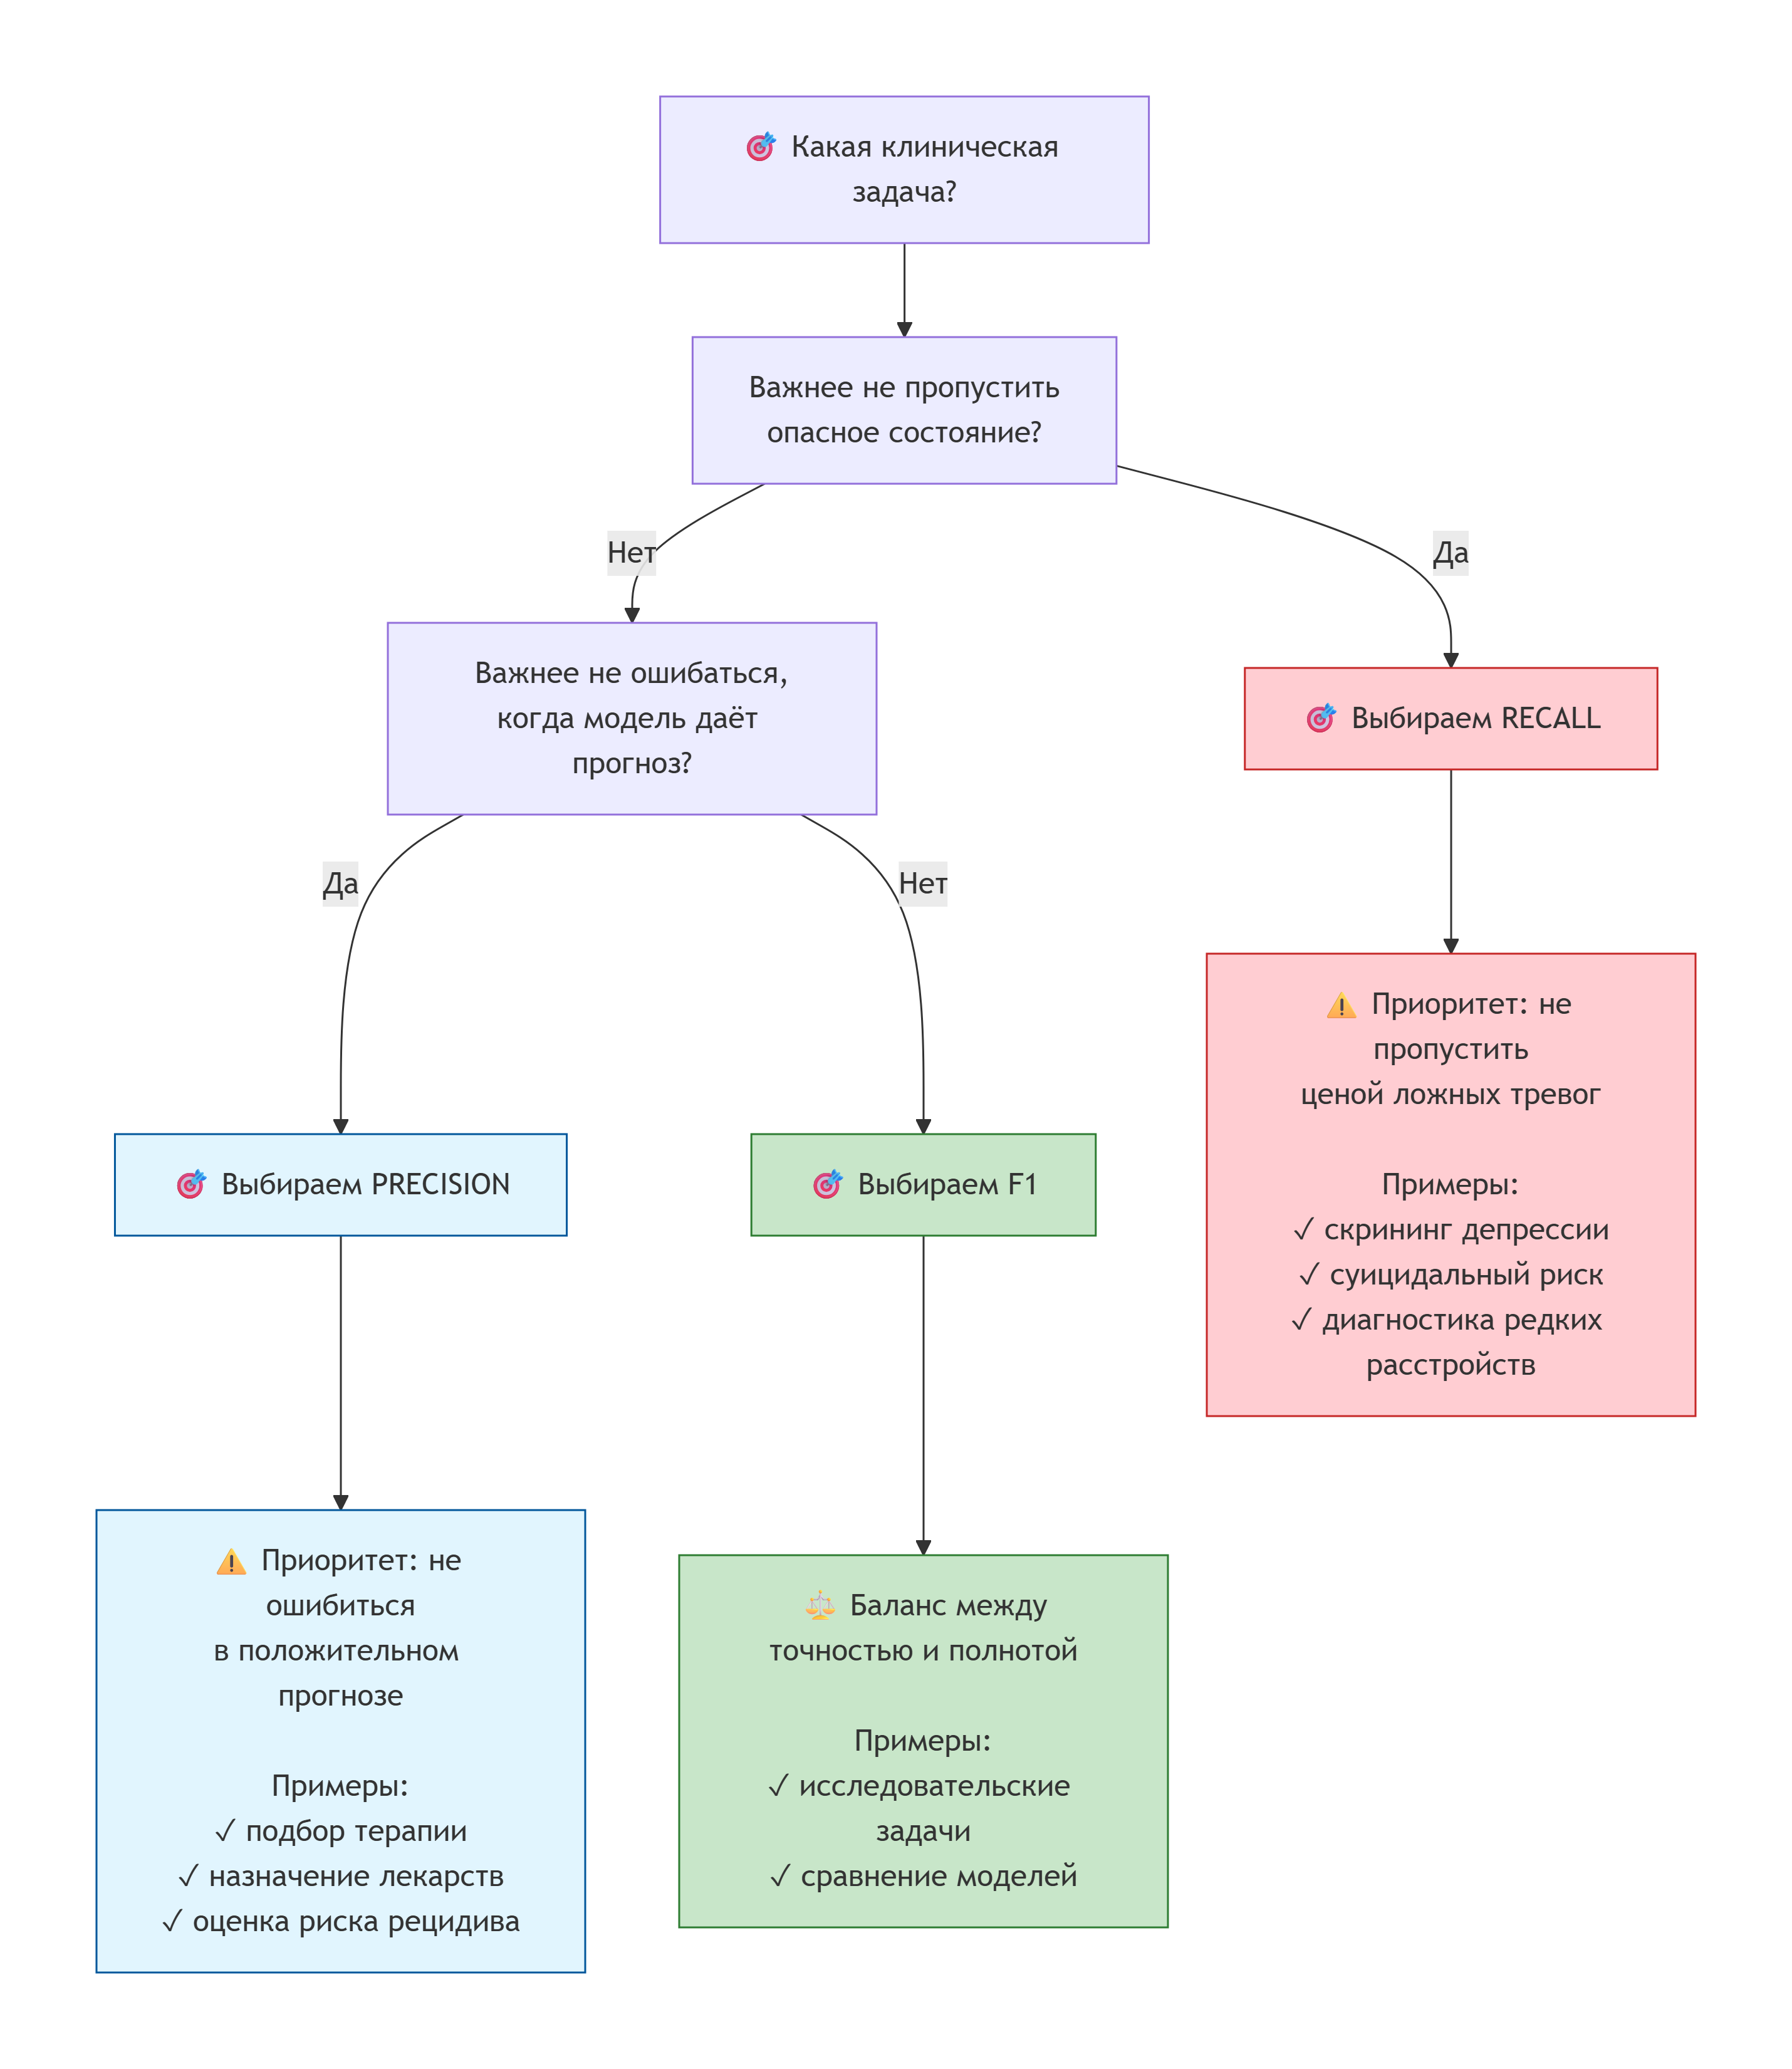



### 6.11. Код для расчёта метрик и визуализации




In [ ]:
# Ячейка 1: Расчёт метрик на синтетических данных

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Создаём синтетические данные для демонстрации
np.random.seed(42)
n_samples = 1000

# Правильные метки: 90% здоровых (0), 10% больных (1)
true_labels = np.array([0] * 900 + [1] * 100)

# Предсказания модели: находит 70% больных, 50 ложных тревог
predicted_labels = np.array(
    [0] * 850 + [1] * 50 +   # 850 верно здоровых, 50 ложных тревог
    [1] * 70 + [0] * 30      # 70 найдено больных, 30 пропущено
)

# 1. Матрица ошибок
cm = confusion_matrix(true_labels, predicted_labels)
print("📊 Матрица ошибок:")
print(cm)
print()
print("Интерпретация:")
print(f"  True Negative (TN): {cm[0,0]} — правильно определили здоровых")
print(f"  False Positive (FP): {cm[0,1]} — ложные тревоги")
print(f"  False Negative (FN): {cm[1,0]} — пропущенные больные (опасно!)")
print(f"  True Positive (TP): {cm[1,1]} — правильно выявленные больные")

# 2. Расчёт метрик
accuracy = accuracy_score(true_labels, predicted_labels)
precision = precision_score(true_labels, predicted_labels)
recall = recall_score(true_labels, predicted_labels)
f1 = f1_score(true_labels, predicted_labels)

print("\n📈 Метрики качества:")
print(f"  Accuracy:  {accuracy:.4f}  ({accuracy*100:.1f}%)")
print(f"  Precision: {precision:.4f}  ({precision*100:.1f}%)")
print(f"  Recall:    {recall:.4f}  ({recall*100:.1f}%)")
print(f"  F1-score:  {f1:.4f}  ({f1*100:.1f}%)")

# 3. Детальный отчёт
print("\n📋 Детальный отчёт по классам (класс 1 = 'депрессия'):")
print(classification_report(true_labels, predicted_labels,
                           target_names=['Здоров', 'Депрессия']))



### 6.12. Основные выводы раздела

1. **Метрики качества** — это объективные числовые показатели, которые позволяют оценить работу модели и сравнивать разные модели между собой.

2. **Accuracy** может быть обманчивой при несбалансированных классах. В клинической психологии она часто не является главной метрикой.

3. **Матрица ошибок** — основа для понимания всех метрик. Она показывает не только правильные ответы, но и типы ошибок (FP и FN).

4. **Precision** показывает, насколько можно доверять положительным предсказаниям модели. Формула: $$Precision = \frac{TP}{TP + FP}$$

5. **Recall** показывает, насколько хорошо модель находит все положительные случаи. Формула: $$Recall = \frac{TP}{TP + FN}$$

6. **F1-score** даёт баланс между precision и recall. Формула: $$F1 = 2 \times \frac{Precision \times Recall}{Precision + Recall}$$

7. Выбор метрики определяется **клинической задачей** и ценой разных типов ошибок. Нет универсальной метрики.

8. В реальной практике используют **несколько метрик одновременно**, чтобы получить полную картину качества модели [5].

9. Понимание метрик позволяет клиницисту **критически оценивать** исследования: если авторы сообщают только accuracy при несбалансированных классах — это повод для скепсиса.



## 7. СВЯЗЬ С ДООБУЧЕНИЕМ (FINE-TUNING)

### 7.1. Что такое дообучение и зачем оно нужно

**Определение:** дообучение (fine-tuning) — это процесс, при котором мы берём **предобученную модель** (которая уже имеет общие знания о языке) и **донастраиваем** её на **конкретной задаче** (например, классификация эмоций, скрининг депрессии) [1], [2].

**Интуитивная аналогия из психологии:**

> Представьте, что вы — клинический психолог, который только что закончил университет. Вы прочитали все учебники, знаете теории Фрейда, Роджерса, Бека, сдали все экзамены. Это ваше **предобучение** — у вас есть общие знания, но нет клинического опыта.
>
> Теперь вы приходите на работу в клинику и начинаете работать с реальными пациентами. Вы проходите **супервизию** — опытный коллега показывает вам, как применять теорию к конкретным случаям. Вы учитесь на реальных примерах, корректируете свой подход, становитесь более точным в диагностике.
>
> Это и есть **дообучение**. Модель берёт свои общие знания языка и адаптирует их к конкретной задаче.

**Почему дообучение эффективно:**

| Причина | Объяснение | Аналогия |
|---------|------------|----------|
| **Экономия ресурсов** | Модель уже знает язык — не нужно учить с нуля | Психолог уже знает теорию — не нужно переучивать с нуля |
| **Меньше данных** | Для дообучения нужно гораздо меньше данных, чем для обучения с нуля | Для супервизии нужно меньше случаев, чем для всего образования |
| **Скорость обучения** | Дообучение происходит за часы, а не за недели | Супервизия занимает месяцы, а не годы |
| **Сохранение знаний** | Модель сохраняет общие знания языка, адаптируя их под задачу | Психолог сохраняет теоретические знания, применяя их к практике |

**Связь с концепциями из предыдущих разделов:**

| Концепция | Как она проявляется в дообучении | Ссылка на раздел |
|-----------|----------------------------------|------------------|
| **Параметры** | 178 миллионов параметров модели ruBERT уже настроены на язык. Мы их только слегка корректируем | Раздел 3.1 |
| **Гиперпараметры** | Мы задаём маленький learning rate (2e-5), чтобы не «сломать» знания модели | Раздел 3.2 |
| **Разделение данных** | Мы используем датасет, разделённый на train/validation/test | Раздел 4 |
| **Графики обучения** | Мы следим за графиками, чтобы не переобучить модель | Раздел 5 |
| **Метрики** | Мы оцениваем модель на тестовой выборке с помощью accuracy, precision, recall, F1 | Раздел 6 |

---

### 7.2. Что происходит при дообучении: пошаговый разбор

**Шаг 1. Берём предобученную модель**

Мы загружаем модель, которая уже обучена на огромном корпусе текстов. В случае ruBERT это 178 миллионов параметров, которые уже «понимают» русский язык.

```python
# Загрузка предобученной модели
model = AutoModelForSequenceClassification.from_pretrained(
    "DeepPavlov/rubert-base-cased",  # модель уже знает русский язык
    num_labels=4                     # но мы меняем задачу — теперь 4 класса
)
```

**Интуитивная аналогия:**

> Психолог окончил университет — он знает общую психологию, но не знает специфику работы с конкретным расстройством. Мы берём его знания и адаптируем.

**Шаг 2. Заменяем последний слой**

Предобученная модель была обучена на задачу предсказания слов (MLM — masked language model). Для классификации нам нужен другой последний слой — тот, который будет выдавать вероятности для 4 классов.

| Что было в предобучении | Что стало при дообучении |
|-------------------------|--------------------------|
| Последний слой предсказывал вероятность слов (30 000+ классов) | Последний слой предсказывает вероятность эмоций (4 класса) |
| Модель «угадывала» пропущенные слова | Модель классифицирует эмоции |

**Интуитивная аналогия:**

> Психолог, который всегда работал со взрослыми пациентами, переходит в детскую клинику. Ему нужно изменить свой подход — адаптировать методы под детей. Это как «заменить последний слой» его знаний.

**Шаг 3. Обучаем с маленькой скоростью обучения (learning rate)**

Почему мы используем **маленький learning rate** (2e-5 вместо стандартного 1e-3)?

| Learning rate | Эффект | Почему это важно |
|---------------|--------|------------------|
| **Большой (1e-3)** | Параметры меняются сильно | Можно «сломать» знания, которые модель уже получила |
| **Маленький (2e-5)** | Параметры меняются чуть-чуть | Модель сохраняет общие знания языка, адаптируясь к задаче |

**Интуитивная аналогия:**

> Психолог на супервизии не переучивается с нуля — он просто корректирует свои подходы на основе обратной связи. Если бы он полностью пересматривал свои знания после каждого случая, это было бы хаотично.

```python
# Настройка маленького learning rate
training_args = TrainingArguments(
    learning_rate=2e-5,  # маленький learning rate
    num_train_epochs=2,  # всего 2 эпохи
    ...
)
```

**Шаг 4. Следим за графиками обучения**

Мы строим графики loss и accuracy, чтобы убедиться, что модель не переобучается. В разделе 5 мы подробно разбирали, как читать эти графики.

```python
# Запуск обучения
trainer.train()  # мы следим за графиками во время этого процесса
```

**Шаг 5. Оцениваем на тестовой выборке**

После обучения мы оцениваем модель на тестовой выборке, используя метрики из раздела 6.

```python
# Оценка модели
test_results = trainer.predict(tokenized_dataset["test"])
accuracy = accuracy_score(test_results.label_ids, predictions)
```

---

### 7.3. Схема: процесс дообучения




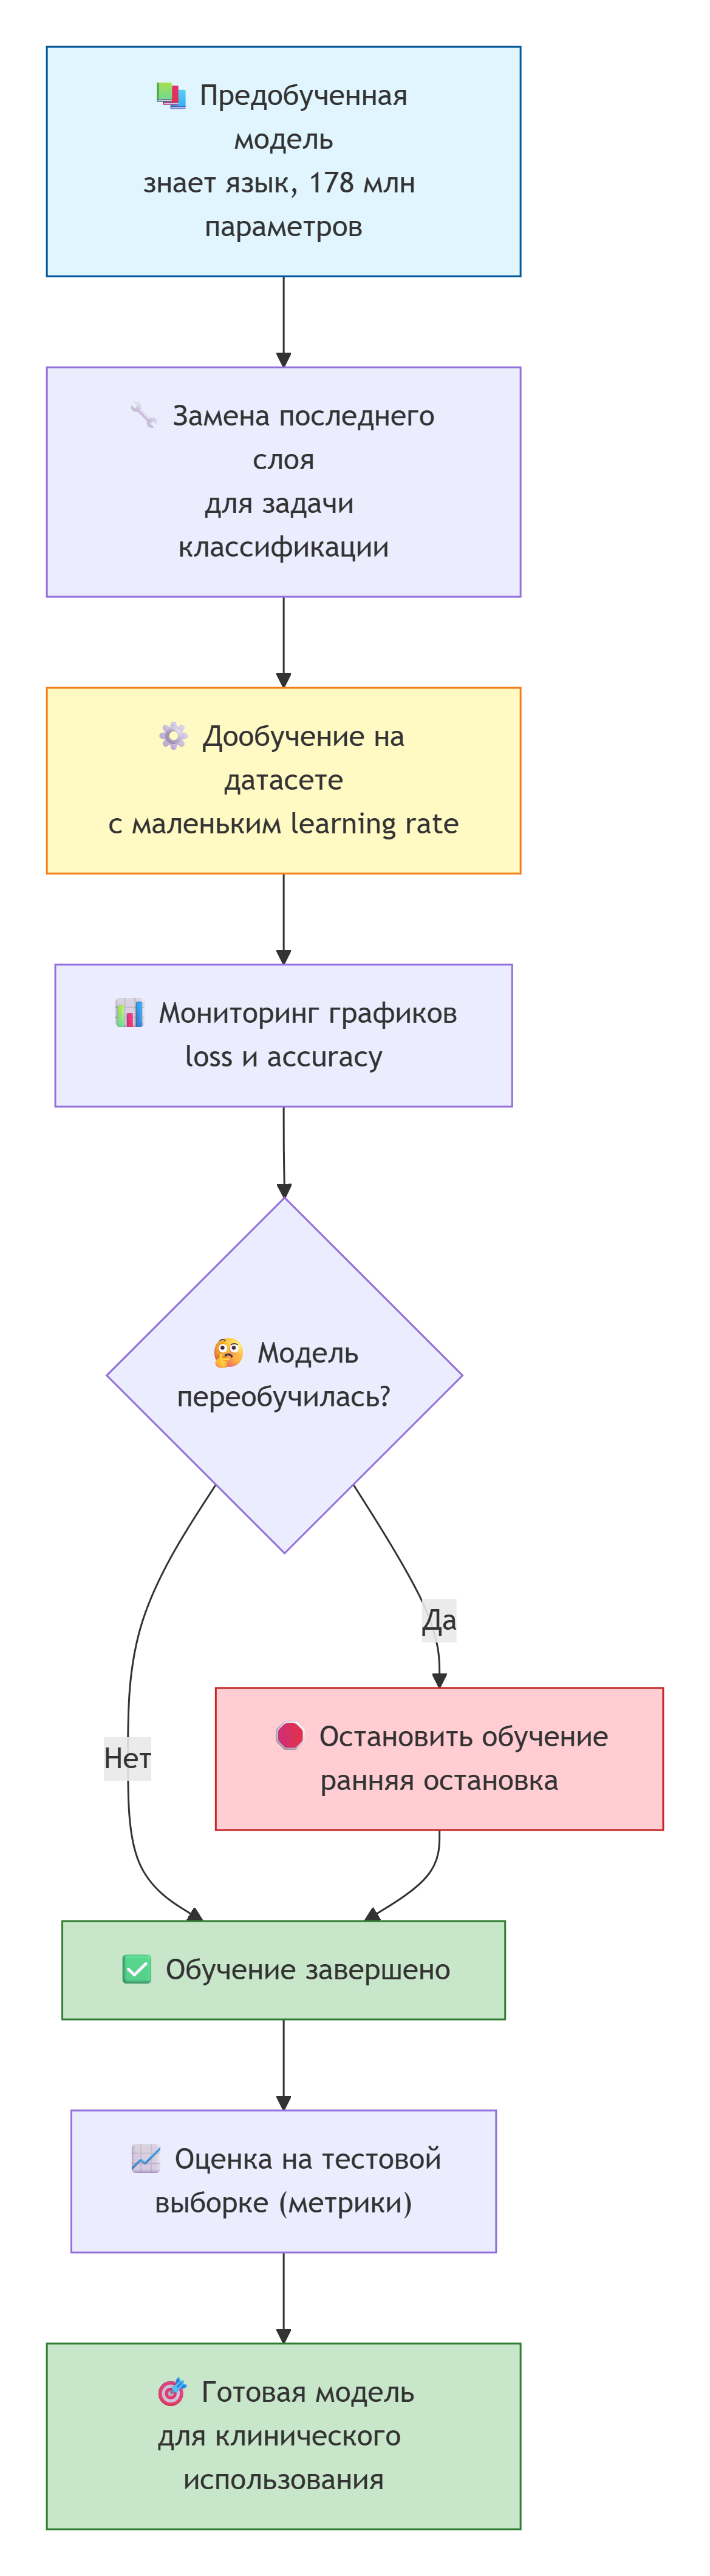


### 7.4. Связь с Практикой 6: что мы делали

В Практике 6 мы выполнили все шаги дообучения на реальном датасете:

| Шаг | Что мы делали в коде | Как это связано с теорией |
|-----|----------------------|---------------------------|
| **1. Загрузка модели** | `AutoModelForSequenceClassification.from_pretrained("DeepPavlov/rubert-base-cased")` | Взяли предобученную модель (Раздел 7.2, Шаг 1) |
| **2. Настройка параметров** | `TrainingArguments(num_labels=4, learning_rate=2e-5, num_train_epochs=2)` | Задали гиперпараметры (Раздел 3) |
| **3. Токенизация** | `tokenizer(text, padding=True, truncation=True)` | Превратили текст в числа (Лекция 3) |
| **4. Обучение** | `trainer.train()` | Запустили дообучение (Раздел 7.2, Шаг 3) |
| **5. Графики** | `plt.plot(loss_history)` | Построили графики обучения (Раздел 5) |
| **6. Оценка** | `trainer.predict(tokenized_dataset["test"])` | Оценили на тестовой выборке (Раздел 6) |
| **7. Метрики** | `accuracy_score, precision_score, recall_score, f1_score` | Посчитали все метрики качества (Раздел 6) |

---

### 7.5. Почему дообучение так эффективно в клинической психологии

**Причина 1: Модель уже понимает язык**

Предобученная модель уже знает грамматику, семантику, контекст. Ей не нужно учить русский язык — она уже это сделала на миллиардах текстов. Мы только адаптируем её под нашу задачу.

**Причина 2: Нужно мало размеченных данных**

Для обучения с нуля нужны сотни тысяч размеченных примеров. Для дообучения достаточно нескольких тысяч (в Практике 6 мы использовали 10 000). Это особенно важно в клинической психологии, где размеченные данные дороги и редки.

**Причина 3: Быстрое обучение**

Дообучение занимает часы или минуты, а не недели. Это позволяет быстро экспериментировать и улучшать модели.

**Причина 4: Переносимость знаний**

Знания, полученные на одной задаче (например, понимание языка), помогают решать другие задачи (например, классификацию эмоций). Это называется **переносом обучения** (transfer learning).

**Интуитивная аналогия:**

> Психолог, который знает общую психологию, быстрее осваивает новое направление (например, работу с ПТСР), чем человек, который только начинает учиться. Он переносит свои знания на новую область.

---

### 7.6. Практические рекомендации для дообучения в клинических задачах

| Параметр | Рекомендация | Почему |
|----------|--------------|--------|
| **Learning rate** | 2e-5 — 5e-5 | Маленький learning rate сохраняет общие знания модели [6] |
| **Число эпох** | 2–4 эпохи | Больше эпох → риск переобучения |
| **Размер батча** | 16–32 | Зависит от вычислительных ресурсов |
| **Weight decay** | 0.01–0.05 | Помогает предотвратить переобучение |
| **Early stopping** | Использовать | Останавливает обучение при росте val loss |
| **Стратификация** | Обязательно | Сохраняет пропорцию классов в выборках |

**Типичные ошибки при дообучении:**

| Ошибка | Последствия | Как избежать |
|--------|-------------|--------------|
| **Слишком большой learning rate** | Модель «забывает» общие знания языка | Использовать 2e-5 или меньше |
| **Слишком много эпох** | Переобучение на обучающей выборке | Использовать early stopping |
| **Нет стратификации** | Неравномерное распределение классов в выборках | Использовать `stratify=y` в `train_test_split` |
| **Не смотрим на графики** | Не видим, когда модель начинает переобучаться | Строить графики loss и accuracy |

---

### 7.7. Схема: от предобучения к дообучению в клинической практике




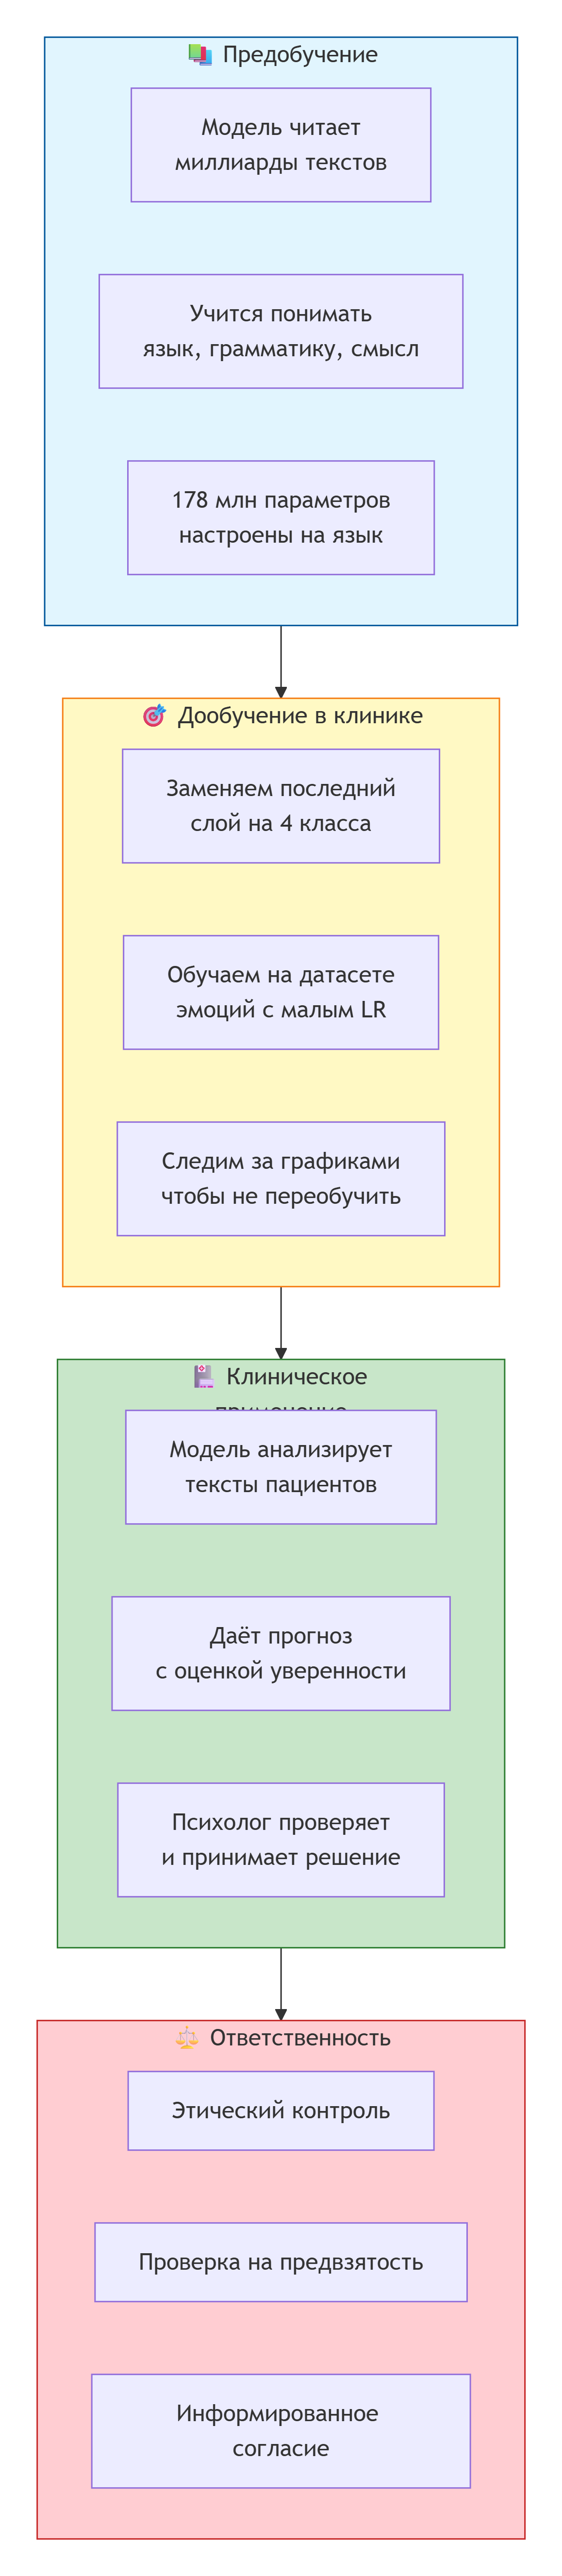


### 7.8. Этический аспект дообучения в клинической психологии

**Ключевое предостережение:** дообучение делает модель более точной на конкретной задаче, но не гарантирует, что она будет правильно работать на всех пациентах. Модель может быть предвзятой, если обучающие данные нерепрезентативны.

**Этические риски при дообучении:**

| Риск | Описание | Как минимизировать |
|------|----------|-------------------|
| **Предвзятость** | Модель может хуже работать на определённых группах пациентов (пол, возраст, культура) | Использовать разнообразные данные для дообучения |
| **Переобучение** | Модель хорошо работает на обучающих данных, но плохо — на новых | Следить за графиками, использовать раннюю остановку |
| **Конфиденциальность** | Данные пациентов могут быть использованы для обучения | Анонимизировать данные, использовать локальное развёртывание |
| **Непроверенные прогнозы** | Модель может ошибаться на сложных клинических случаях | Всегда проверять прогнозы модели человеком |

**Что должен сделать клиницист перед внедрением дообученной модели:**

1. **Проверить данные** — насколько они репрезентативны для вашей популяции пациентов.
2. **Проверить метрики** — имеет ли модель достаточно высокий recall (если задача — скрининг).
3. **Проверить на разных группах** — не хуже ли модель работает на определённых пациентах (женщины, пожилые и т.д.).
4. **Создать протокол** — как будут проверяться прогнозы модели перед принятием клинических решений.
5. **Получить информированное согласие** — пациент должен знать, что его данные анализируются моделью.

**Ключевая этическая мысль:**

> Модель — это инструмент. Она может ошибаться. В психиатрии ошибочный прогноз может иметь серьёзные последствия. Доверяйте, но проверяйте. Понимание того, как работает дообучение, — это первый шаг к ответственному использованию ИИ в клинике.

---

### 7.9. Основные выводы раздела

1. **Дообучение (fine-tuning)** — это процесс адаптации предобученной модели к конкретной задаче. Модель уже знает язык, мы только настраиваем её под нашу задачу.

2. **Замена последнего слоя** — ключевой шаг: мы убираем слой для предсказания слов и добавляем слой для классификации эмоций (или другой задачи).

3. **Маленький learning rate** — мы используем 2e-5, чтобы не «сломать» знания, которые модель уже получила.

4. **Мониторинг графиков** — мы следим за loss и accuracy, чтобы вовремя остановить обучение при переобучении.

5. **Эффективность дообучения** — требует меньше данных, времени и вычислительных ресурсов, чем обучение с нуля.

6. **Перенос знаний** — модель переносит знания языка на новую клиническую задачу.

7. **Этическая ответственность** — дообученная модель может быть предвзятой, если данные нерепрезентативны. Все прогнозы должны проверяться психологом.

8. **Связь с практикой** — в Практике 6 мы выполнили все шаги дообучения на реальном датасете эмоций.

---

### 7.10. Полный код для дообучения: от загрузки данных до оценки модели

**Пояснение:** ниже представлен **полный, самодостаточный код** для дообучения модели BERT на задачу классификации эмоций. Он включает все этапы, которые мы обсуждали в лекции. Код готов к копированию и запуску в **Google Colab** (бесплатная облачная среда).




In [ ]:
# ============================================================
# ПОЛНЫЙ КОД ДЛЯ ДООБУЧЕНИЯ BERT НА КЛАССИФИКАЦИЮ ЭМОЦИЙ
# ============================================================
#
# Этот код можно скопировать в Google Colab и запустить.
# Он создаёт синтетический датасет, дообучает ruBERT,
# строит графики обучения и оценивает качество модели.
# ============================================================

# ============================================================
# 1. УСТАНОВКА И ИМПОРТ БИБЛИОТЕК
# ============================================================

# Установка библиотек (выполняется один раз)
!pip install transformers datasets scikit-learn matplotlib seaborn

# Импорт библиотек
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)
from datasets import Dataset, DatasetDict
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback
)

print("✅ Библиотеки загружены!")

# ============================================================
# 2. СОЗДАНИЕ СИНТЕТИЧЕСКОГО ДАТАСЕТА
# ============================================================

# Определяем словари фраз для каждого класса эмоций
emotion_phrases = {
    0: [  # Гнев
        "Я больше не могу это терпеть!",
        "Как они посмели так поступить?",
        "Это просто невыносимо!",
        "Меня всё бесит!",
        "Я в ярости от происходящего!",
        "Это несправедливо!",
        "Я срываюсь на всех!",
        "Мне надоело это терпеть!",
        "Я просто взбешён!",
        "Как они могли так поступить со мной?"
    ],
    1: [  # Страх
        "Мне кажется, что за мной следят.",
        "Я боюсь выходить из дома.",
        "У меня панические атаки.",
        "Мне страшно оставаться одной.",
        "Я постоянно тревожусь.",
        "Мне кажется, что случится что-то ужасное.",
        "У меня дрожит сердце от страха.",
        "Я не могу избавиться от этого ужаса.",
        "Каждый день я просыпаюсь с чувством страха.",
        "Мне страшно за своё будущее."
    ],
    2: [  # Радость
        "Сегодня был лучший день в моей жизни!",
        "Я так счастлива!",
        "Наконец-то всё наладилось!",
        "Мир прекрасен!",
        "Я чувствую прилив энергии и радости.",
        "У меня всё отлично получается!",
        "Я в восторге от происходящего.",
        "Мне так хорошо и спокойно.",
        "Я просто сияю от счастья!",
        "Никогда не чувствовала себя такой свободной."
    ],
    3: [  # Грусть
        "Я чувствую себя опустошённым.",
        "Ничто не имеет смысла.",
        "Мне так грустно и одиноко.",
        "Жизнь потеряла краски.",
        "Я не вижу выхода из этого состояния.",
        "Всё кажется бессмысленным.",
        "Я плачу каждый день.",
        "Мне так тяжело, что я не могу встать.",
        "Я потеряла интерес к жизни.",
        "Каждый день похож на предыдущий — серый и пустой."
    ]
}

def create_dataset(num_samples_per_class=30):
    """Создаёт синтетический датасет эмоций."""
    data = []
    for label, phrases in emotion_phrases.items():
        for _ in range(num_samples_per_class):
            text = random.choice(phrases)
            # Добавляем небольшие вариации
            if random.random() > 0.6:
                text = text.replace(".", "...")
            data.append({"text": text, "label": label})
    random.shuffle(data)
    return pd.DataFrame(data)

# Создаём датасет
df = create_dataset(num_samples_per_class=30)
print(f"✅ Создано {len(df)} примеров")
print(f"Распределение классов:\n{df['label'].value_counts().sort_index()}")

emotion_names = {0: "Гнев", 1: "Страх", 2: "Радость", 3: "Грусть"}

# ============================================================
# 3. РАЗДЕЛЕНИЕ ДАННЫХ НА TRAIN, VALIDATION, TEST
# ============================================================

X = df['text'].values
y = df['label'].values

# Первое разделение: 70% train, 30% temporary
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

# Второе разделение: 15% validation, 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print("\n📊 Разделение данных:")
print(f"  Train:     {len(X_train)} примеров ({len(X_train)/len(df)*100:.0f}%)")
print(f"  Validation: {len(X_val)} примеров ({len(X_val)/len(df)*100:.0f}%)")
print(f"  Test:      {len(X_test)} примеров ({len(X_test)/len(df)*100:.0f}%)")

# Создаём словари для Hugging Face Dataset
train_data = {"text": X_train.tolist(), "label": y_train.tolist()}
val_data = {"text": X_val.tolist(), "label": y_val.tolist()}
test_data = {"text": X_test.tolist(), "label": y_test.tolist()}

dataset = DatasetDict({
    "train": Dataset.from_dict(train_data),
    "validation": Dataset.from_dict(val_data),
    "test": Dataset.from_dict(test_data)
})

print("\n✅ Датасет готов для обучения!")

# ============================================================
# 4. ТОКЕНИЗАЦИЯ
# ============================================================

model_name = "DeepPavlov/rubert-base-cased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        padding="max_length",
        truncation=True,
        max_length=64  # Уменьшаем для скорости
    )

tokenized_dataset = dataset.map(tokenize_function, batched=True)
print("✅ Токенизация завершена!")

# ============================================================
# 5. ЗАГРУЗКА МОДЕЛИ
# ============================================================

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=4
)

print(f"✅ Модель загружена! Параметров: {model.num_parameters():,}")

# ============================================================
# 6. НАСТРОЙКА ПАРАМЕТРОВ ОБУЧЕНИЯ
# ============================================================

training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=3,                # 3 эпохи
    per_device_train_batch_size=8,     # маленький батч для скорости
    per_device_eval_batch_size=8,
    learning_rate=2e-5,               # маленький learning rate
    warmup_steps=100,
    weight_decay=0.01,
    logging_dir="./logs",
    logging_steps=50,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    report_to="none",                 # не отправляем логи в облако
    save_total_limit=2                # сохраняем только 2 лучшие модели
)

print("\n📊 Параметры обучения:")
print(f"  Learning rate: {training_args.learning_rate}")
print(f"  Number of epochs: {training_args.num_train_epochs}")
print(f"  Batch size: {training_args.per_device_train_batch_size}")

# ============================================================
# 7. ФУНКЦИЯ ДЛЯ РАСЧЁТА МЕТРИК
# ============================================================

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)

    return {
        'accuracy': accuracy_score(labels, predictions),
        'precision': precision_score(labels, predictions, average='weighted'),
        'recall': recall_score(labels, predictions, average='weighted'),
        'f1': f1_score(labels, predictions, average='weighted')
    }

# ============================================================
# 8. СОЗДАНИЕ И ЗАПУСК TRAINER
# ============================================================

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

print("\n🚀 Начинаем обучение...")
trainer.train()
print("✅ Обучение завершено!")

# Сохраняем модель
trainer.save_model("./best_model")
print("✅ Модель сохранена!")

# ============================================================
# 9. ОЦЕНКА НА ТЕСТОВОЙ ВЫБОРКЕ
# ============================================================

print("\n📊 Оценка на тестовой выборке...")
test_results = trainer.predict(tokenized_dataset["test"])

predictions = np.argmax(test_results.predictions, axis=1)
true_labels = test_results.label_ids

# Расчёт метрик
accuracy = accuracy_score(true_labels, predictions)
precision = precision_score(true_labels, predictions, average='weighted')
recall = recall_score(true_labels, predictions, average='weighted')
f1 = f1_score(true_labels, predictions, average='weighted')

print("\n📈 Результаты на тестовой выборке:")
print(f"  Accuracy:  {accuracy:.4f}  ({accuracy*100:.1f}%)")
print(f"  Precision: {precision:.4f}  ({precision*100:.1f}%)")
print(f"  Recall:    {recall:.4f}  ({recall*100:.1f}%)")
print(f"  F1-score:  {f1:.4f}  ({f1*100:.1f}%)")

# Детальный отчёт
print("\n📋 Детальный отчёт по каждому классу:")
print(classification_report(true_labels, predictions,
                           target_names=list(emotion_names.values())))

# ============================================================
# 10. ПОСТРОЕНИЕ ГРАФИКОВ ОБУЧЕНИЯ
# ============================================================

# Извлекаем историю обучения из логов
log_history = trainer.state.log_history

train_losses = []
eval_losses = []
eval_accuracies = []
steps = []

for log in log_history:
    if 'loss' in log:
        train_losses.append(log['loss'])
        steps.append(log['step'])
    if 'eval_loss' in log:
        eval_losses.append(log['eval_loss'])
    if 'eval_accuracy' in log:
        eval_accuracies.append(log['eval_accuracy'])

# Проверяем, есть ли данные
if len(train_losses) == 0:
    print("\n⚠️ Нет данных логов для построения графиков.")
    print("Возможно, обучение заняло меньше 50 шагов.")
else:
    # Создаём графики
    plt.figure(figsize=(14, 5))

    # График 1: Loss
    plt.subplot(1, 2, 1)
    plt.plot(steps, train_losses, 'b-', label='Train Loss', linewidth=2)
    if eval_losses:
        eval_steps = [log['step'] for log in log_history if 'eval_loss' in log]
        plt.plot(eval_steps, eval_losses, 'r-', label='Validation Loss', linewidth=2)
    plt.xlabel('Шаг обучения', fontsize=12)
    plt.ylabel('Loss (ошибка)', fontsize=12)
    plt.title('Динамика ошибки в процессе обучения', fontsize=14)
    plt.legend()
    plt.grid(True, alpha=0.3)

    # График 2: Accuracy
    plt.subplot(1, 2, 2)
    if eval_accuracies:
        eval_steps = [log['step'] for log in log_history if 'eval_accuracy' in log]
        plt.plot(eval_steps, eval_accuracies, 'g-', label='Validation Accuracy', linewidth=2, marker='o')
    plt.xlabel('Шаг обучения', fontsize=12)
    plt.ylabel('Accuracy (точность)', fontsize=12)
    plt.title('Динамика точности в процессе обучения', fontsize=14)
    plt.ylim(0, 1.0)
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('training_plots.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("✅ Графики сохранены как 'training_plots.png'")

# ============================================================
# 11. ВИЗУАЛИЗАЦИЯ МАТРИЦЫ ОШИБОК
# ============================================================

cm = confusion_matrix(true_labels, predictions)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=list(emotion_names.values()),
            yticklabels=list(emotion_names.values()))
plt.xlabel('Предсказанный класс', fontsize=12)
plt.ylabel('Правильный класс', fontsize=12)
plt.title('Матрица ошибок классификатора эмоций', fontsize=14)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Матрица ошибок сохранена как 'confusion_matrix.png'")

# ============================================================
# 12. ИТОГОВЫЙ ВЫВОД
# ============================================================

print("\n" + "="*60)
print("📊 ИТОГОВЫЕ РЕЗУЛЬТАТЫ ДООБУЧЕНИЯ")
print("="*60)
print(f"  Accuracy:  {accuracy:.4f}  ({accuracy*100:.1f}%)")
print(f"  Precision: {precision:.4f}  ({precision*100:.1f}%)")
print(f"  Recall:    {recall:.4f}  ({recall*100:.1f}%)")
print(f"  F1-score:  {f1:.4f}  ({f1*100:.1f}%)")
print("="*60)

print("\n✅ Дообучение успешно завершено!")
print("📁 Модель сохранена в папке './best_model'")
print("📊 Графики сохранены как 'training_plots.png'")
print("📊 Матрица ошибок сохранена как 'confusion_matrix.png'")


### Пояснение к коду

| Раздел кода | Что делает | Связь с лекцией |
|-------------|------------|-----------------|
| **1. Установка библиотек** | Устанавливает необходимые библиотеки | — |
| **2. Создание датасета** | Генерирует синтетические тексты эмоций | Раздел 4.6 |
| **3. Разделение данных** | Делит на train/validation/test (70/15/15) | Раздел 4 |
| **4. Токенизация** | Превращает текст в числа | Лекция 3 |
| **5. Загрузка модели** | Загружает предобученный ruBERT | Раздел 7.2 |
| **6. Настройка параметров** | Learning rate = 2e-5, эпохи = 3 | Раздел 3.2 |
| **7. Функция метрик** | Accuracy, precision, recall, F1 | Раздел 6 |
| **8. Запуск обучения** | Trainer.train() с Early Stopping | Раздел 7.2 |
| **9. Оценка на тесте** | Расчёт метрик на тестовой выборке | Раздел 6 |
| **10. Графики обучения** | Визуализация loss и accuracy | Раздел 5 |
| **11. Матрица ошибок** | Тепловая карта ошибок | Раздел 6.2 |
| **12. Итоговый вывод** | Сводка результатов | — |




## 8. ЗАКЛЮЧЕНИЕ

**Что мы сегодня узнали:**

| Что узнали | Ключевая идея | Аналогия для психолога |
|------------|---------------|----------------------|
| **Что такое обучение** | Настройка параметров модели для уменьшения ошибки | Терапевт учится на супервизии |
| **Функция потерь** | Измеряет, насколько модель ошиблась | Оценка ошибки студента |
| **Градиентный спуск** | Алгоритм, который показывает, куда двигаться | Спуск с горы в тумане |
| **Параметры vs гиперпараметры** | Параметры учит модель, гиперпараметры задаём мы | Веса терапевта (параметры) vs условия супервизии (гиперпараметры) |
| **Разделение данных** | Train, validation, test — три разные выборки | Учебные кейсы, контрольные, экзамен |
| **Графики обучения** | Как читать loss и accuracy, распознавать переобучение | Как понять, что терапевт запоминает случаи, а не учится |
| **Метрики** | Accuracy, precision, recall, F1 — разные взгляды на качество | В психологии recall важнее accuracy (не пропустить депрессию) |

**Ключевая мысль на сегодня:**

> Понимание процесса обучения — это не «техническая деталь». Это **ключ к критической оценке** любой ИИ-системы. Если вы понимаете, как модель учится, вы понимаете, когда ей можно доверять, а когда — нет. В психологии, где цена ошибки высока, это знание становится **этической необходимостью**.

**Связь с будущим:**
- В следующих лекциях мы будем говорить о **конкретных применениях** ИИ в психологии — диагностика, персонализация терапии, прогнозирование исходов.
- Понимание процесса обучения поможет вам **задавать правильные вопросы** к этим системам: *«На каких данных она обучена? Как она делила выборку? Не переобучилась ли она? Какую метрику она оптимизировала?»*

---

## 9. ВОПРОСЫ ДЛЯ САМОПРОВЕРКИ (10 шт.)

1. Что такое функция потерь (loss function)? Приведите аналогию из психотерапии.

2. Что такое градиентный спуск? Объясните на примере спуска с горы.

3. В чём разница между параметрами и гиперпараметрами модели? Приведите примеры тех и других.

4. Зачем делить данные на train, validation и test? Что произойдёт, если использовать test для настройки гиперпараметров?

5. Что такое утечка данных (data leakage)? Приведите пример в контексте психологического исследования.

6. Как выглядит график обучения при переобучении (overfitting)? Что нужно сделать, чтобы исправить ситуацию?

7. Как выглядит график обучения при недообучении (underfitting)? Что нужно сделать, чтобы исправить ситуацию?

8. Что такое precision и recall? Какая метрика важнее для скрининга депрессии и почему?

9. Что такое F1-score и когда его используют?

10. **Этический вопрос:** представьте, что модель для выявления суицидального риска показывает precision = 90% и recall = 60%. Можно ли её использовать в клинике? Почему да или почему нет?

---

## 10. ДОМАШНЕЕ ЗАДАНИЕ (срок — 2 недели)

**Часть 1. Анализ графиков обучения (2–3 страницы)**

Вам даны три набора графиков обучения (воображаемых). Для каждого набора определите состояние обучения и предложите действия.

**Набор А:**
- Train loss: 2.5 → 1.2 → 0.8 → 0.7 → 0.65
- Val loss: 2.6 → 1.5 → 1.1 → 1.2 → 1.4
- Train acc: 0.40 → 0.60 → 0.75 → 0.80 → 0.82
- Val acc: 0.38 → 0.55 → 0.65 → 0.63 → 0.60

**Набор Б:**
- Train loss: 2.5 → 2.4 → 2.3 → 2.3 → 2.2
- Val loss: 2.6 → 2.5 → 2.4 → 2.4 → 2.3
- Train acc: 0.40 → 0.42 → 0.43 → 0.44 → 0.44
- Val acc: 0.38 → 0.39 → 0.40 → 0.40 → 0.41

**Набор В:**
- Train loss: 2.5 → 1.0 → 0.5 → 0.3 → 0.2
- Val loss: 2.6 → 1.5 → 1.0 → 0.9 → 0.85
- Train acc: 0.40 → 0.70 → 0.85 → 0.92 → 0.95
- Val acc: 0.38 → 0.60 → 0.72 → 0.74 → 0.73

---

**Часть 2. Выбор метрики для психологической задачи (2 страницы)**

Даны три клинические задачи. Для каждой определите главную метрику и объясните почему.

**Задача А.** Модель для скрининга депрессии в общей популяции (депрессия у 5% людей).

**Задача Б.** Модель для подбора терапии: определяет, подойдёт ли пациенту КПТ или медикаментозное лечение.

**Задача В.** Модель для выявления суицидального риска по текстам постов в социальных сетях.

---

**Часть 3. Рефлексия о переобучении в психологии (1–2 страницы)**

Напишите эссе на тему: *«Может ли терапевт "переобучиться"? И что мы можем сделать, чтобы этого избежать?»*

Включите:
- Аналогию между переобучением модели и «запоминанием случаев» в психотерапии.
- Какие практики в психотерапии помогают терапевту «обобщать», а не «запоминать»?
- Как супервизия, интервизия, работа с разными пациентами и постоянное обучение помогают избежать «клинического переобучения»?

---

**Часть 4. Дополнительное задание (для желающих) — этический анализ**

Представьте, что вы — клинический психолог. К вам приходит компания-разработчик с предложением внедрить модель для диагностики депрессии по тексту. Модель показывает:
- Accuracy: 92%
- Precision: 88%
- Recall: 70%

Напишите краткий отчёт (1 страница):
- Согласитесь ли вы использовать эту модель в своей практике?
- Какие вопросы вы зададите разработчикам перед внедрением?
- Какие меры предосторожности вы предложите?

---

## 11. ЛИТЕРАТУРА

1. Goodfellow, I., Bengio, Y., & Courville, A. (2016). *Deep Learning*. MIT Press.
2. Chollet, F. (2021). *Deep Learning with Python* (2nd ed.). Manning Publications.
3. Géron, A. (2023). *Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow* (3rd ed.). O'Reilly.
4. Scikit-learn Documentation (2024). *Model evaluation: metrics*. https://scikit-learn.org/stable/modules/model_evaluation.html
5. Крылов, В. (2025). *Метрики классификации в клинической психологии: выбор и интерпретация*. Журнал медицинской психологии, 14(2), 45–53.
6. Hugging Face Documentation (2024). *Fine-tuning with Trainer*. https://huggingface.co/docs/transformers/en/training
7. Севостьянов, А. (2024). *Интерпретация графиков обучения нейросетей: руководство для психологов*. Когнитивные науки и психология, 9(1), 78–89.


## 4. ЛИТЕРАТУРА (ДЛЯ ПЕРВОЙ ЧАСТИ)

1. Goodfellow, I., Bengio, Y., & Courville, A. (2016). *Deep Learning*. MIT Press.
2. Chollet, F. (2021). *Deep Learning with Python* (2nd ed.). Manning Publications.
3. Géron, A. (2023). *Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow* (3rd ed.). O'Reilly.
4. Scikit-learn Documentation (2024). *Model evaluation: metrics*. https://scikit-learn.org/stable/modules/model_evaluation.html
5. Крылов, В. (2025). *Метрики классификации в клинической психологии: выбор и интерпретация*. Журнал медицинской психологии, 14(2), 45–53.
6. Hugging Face Documentation (2024). *Fine-tuning with Trainer*. https://huggingface.co/docs/transformers/en/training
7. Севостьянов, А. (2024). *Интерпретация графиков обучения нейросетей: руководство для психологов*. Когнитивные науки и психология, 9(1), 78–89.